In [1]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config
from matplotlib import rcParams, rcParamsDefault
import matplotlib.colors as mcolors


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False
eid = "E118"
fold = 0
# remove_marks = "H3K36me3"
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]


d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

if remove_marks:
    checkpoints = f"checkpoints/{eid}.remove_{remove_marks}.{fold}.bs_bf_para.model.pt"
else:
    checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"


binsizes = [500]


#
# Setup end.
#

seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

# Split genes into two sets (train/val).
genes = set(meta.gene_id.unique())
n_genes = len(genes)
print("Target genes:", len(genes))
print(f"n_feats_p:{n_feats_p}")

splits = {
    1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
    2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
    3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
    4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
}

chromosome_splits = {}
for key, chroms in splits.items():
    for chrom in chroms:
        chromosome_splits[chrom] = key

qs = [
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
    meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
]

train_genes = (
    qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
)
val_genes = qs[(fold + 3) % 4]



print(len(train_genes), len(val_genes))

val_dataset = DeepBurstDataset(
    meta_path,
    npy_dir,
    val_genes,
    i_max,
    binsizes,
    w_prom,
    w_max,
    config = config,
    with_gene_id=True
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

model = DeepBurst(
    n_feats_p,
    # 
    d_emb,
    d_head,
    embed_kws=embed_kws,
    binsizes=binsizes,
    seed=42,
    targets=targets,
    # 
).to(DEVICE)

ckpt = torch.load(checkpoints,map_location=DEVICE)
model.load_state_dict(ckpt["net"])
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target genes: 14307
n_feats_p:7
10838 3469


In [2]:
def evaluation(out:'torch.Tensor', label:torch.Tensor):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return label, pred, acc, auc, ap

In [3]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]



# BS pred score marks strength

In [5]:
from scripts.utils import bin_and_padding

for _eid in ['E118','E116','E003']:
    # data = pd.read_csv(f'extra/results/{_eid}_predictions_bs_bf.csv')
    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{_eid}_delay_1.0_with_cellsize_1.csv"

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')

    high_gene_ids = list(meta[meta['bs_label']==1][['gene_id','strand']].values)
    high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
    high_marks = np.mean(high_marks, axis=0)
    with open(f"extra/results/{_eid}_bs_para_highmarks.npy", 'wb') as f:
        np.save(f,high_marks)

    low_gene_ids = list(meta[meta['bs_label']==0][['gene_id','strand']].values)
    low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
    low_marks = np.mean(low_marks, axis=0)
    with open(f"extra/results/{_eid}_bs_para_lowmarks.npy", 'wb') as f:
        np.save(f,low_marks)


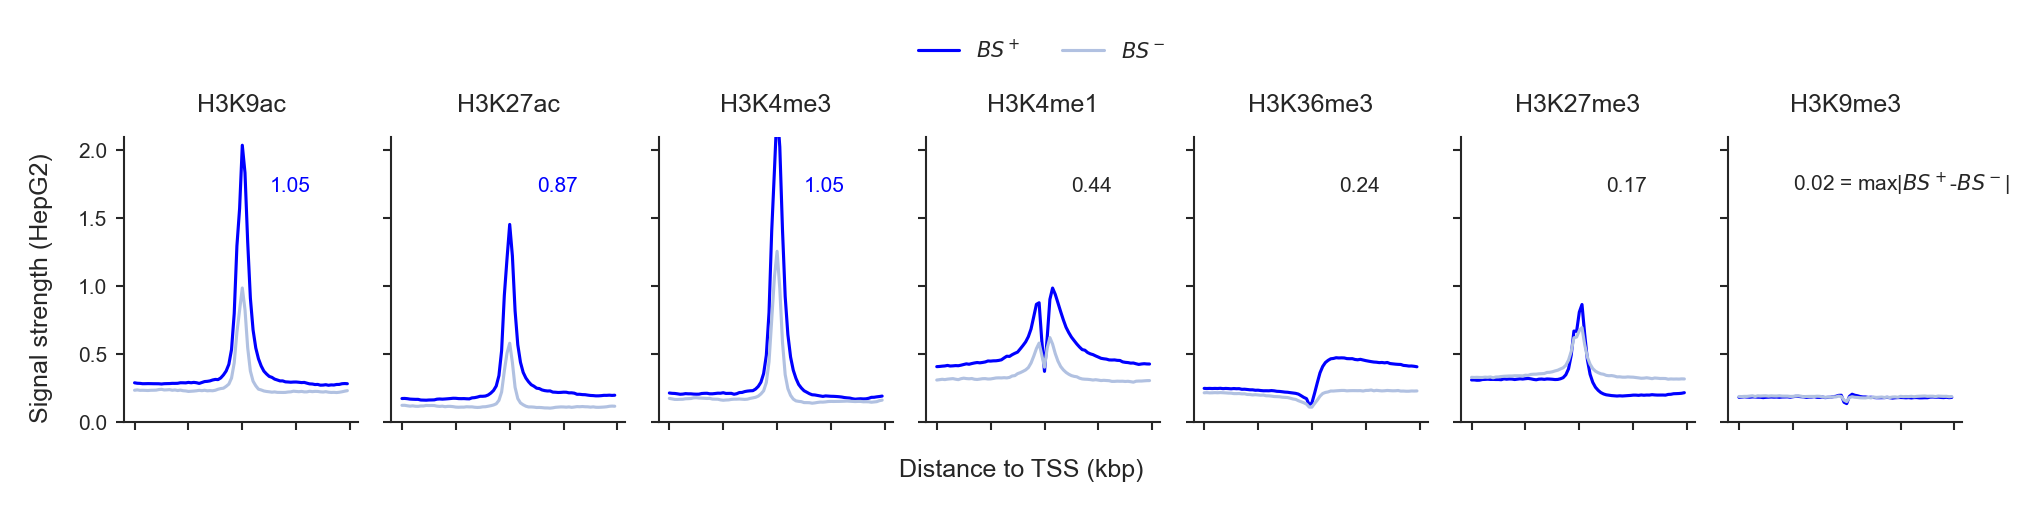

In [6]:
high_marks = np.load(f"extra/results/{eid}_bs_para_highmarks.npy")
low_marks = np.load(f"extra/results/{eid}_bs_para_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(17/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='blue',  ax=ax[idx % 7])
    sns.lineplot(low_marks[_idx], color=(177/255,193/255,225/255),  ax=ax[idx % 7])
    # ax[idx % 7].text(0,1.7,f"max|$BS^+-BF^-$|={round(max(abs(high_marks[_idx]-low_marks[_idx])),2)}",fontdict={"size":5}) 
    if idx < 3:
        ax[idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='blue')
    elif idx ==6:
        ax[idx % 7].text(20,1.7,f"{round(max(abs(high_marks[_idx]-low_marks[_idx])),2)} = max|$BS^+$-$BS^-$|",fontdict={"size":5})
    else:
        ax[idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
    # Set the y-axis ticks
    ax[idx % 7].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
    if idx == 0:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
    else:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[idx % 7].set_title(mark, fontsize=6,fontweight='regular')
    ax[idx % 7].set_ylim(ymax=2.1)
    # Set the xlabel for each subplot

lines = ax[6].get_lines()

handles = [lines[0], lines[1]]
labels = ["$BS^+$", "$BS^-$"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.51, 1.15) , title_fontsize=6,fontsize=5,ncol=4,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
fig.supylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
fig.align_ylabels()
# Adjust layout to ensure everything fits

# plt.savefig(f'extra/figures/Figure4H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


# BF pred score marks strength

In [7]:
from scripts.utils import bin_and_padding

for _eid in ['E118','E116','E003']:
    # data = pd.read_csv(f'extra/results/{_eid}_predictions_bs_bf.csv')
    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{_eid}_delay_1.0_with_cellsize_1.csv"

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')

    high_gene_ids = list(meta[meta['bf_label']==1][['gene_id','strand']].values)
    high_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in high_gene_ids])
    high_marks = np.mean(high_marks, axis=0)
    with open(f"extra/results/{_eid}_bf_para_highmarks.npy", 'wb') as f:
        np.save(f,high_marks)

    low_gene_ids = list(meta[meta['bf_label']==0][['gene_id','strand']].values)
    low_marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in low_gene_ids])
    low_marks = np.mean(low_marks, axis=0)
    with open(f"extra/results/{_eid}_bf_para_lowmarks.npy", 'wb') as f:
        np.save(f,low_marks)


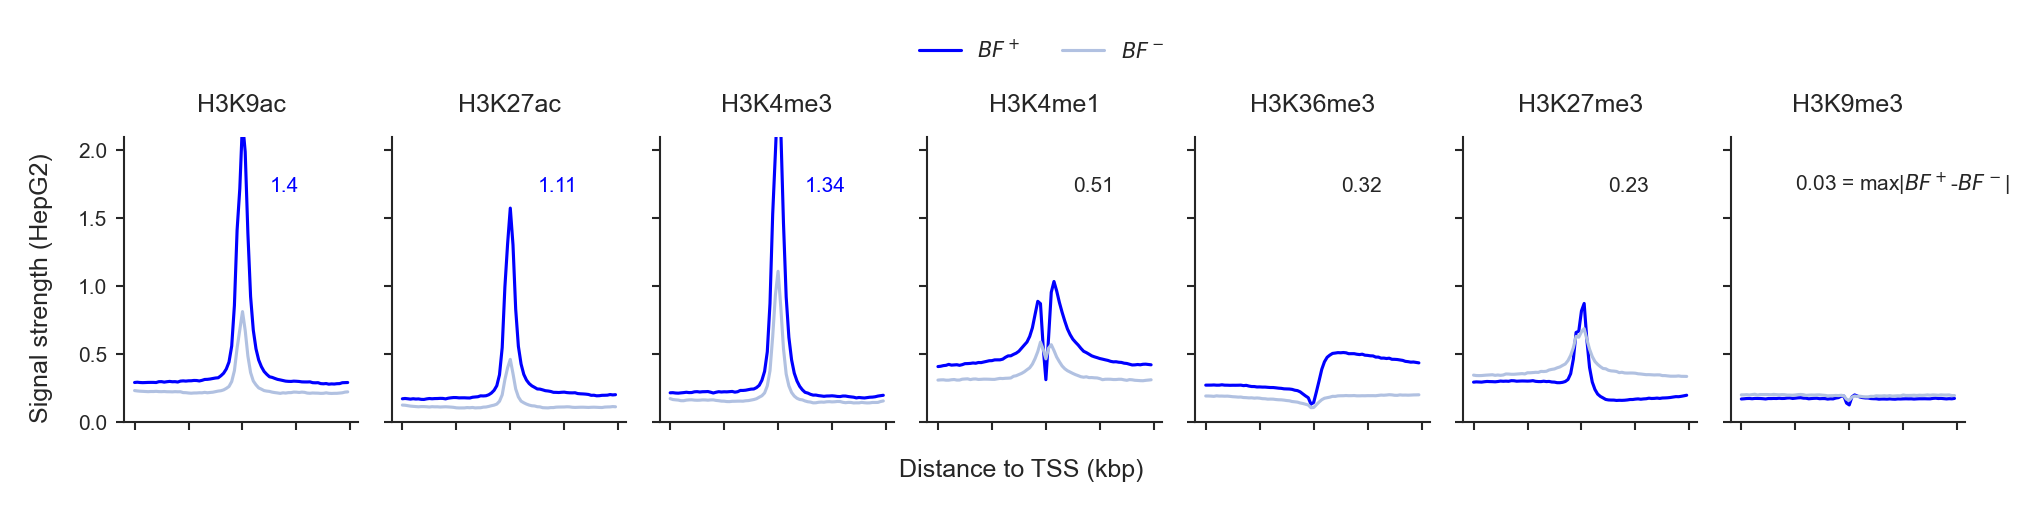

In [8]:
eid = 'E118'
high_marks = np.load(f"extra/results/{eid}_bf_para_highmarks.npy")
low_marks = np.load(f"extra/results/{eid}_bf_para_lowmarks.npy")
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']

fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(17/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    sns.lineplot(high_marks[_idx], color='blue',  ax=ax[idx % 7])
    sns.lineplot(low_marks[_idx], color=(177/255,193/255,225/255),  ax=ax[idx % 7])
    # ax[idx % 7].text(0,1.7,f"max|$BS^+-BF^-$|={round(max(abs(high_marks[_idx]-low_marks[_idx])),2)}",fontdict={"size":5}) 
    if idx < 3:
        ax[idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5}, color='blue')
    elif idx ==6:
        ax[idx % 7].text(20,1.7,f"{round(max(abs(high_marks[_idx]-low_marks[_idx])),2)} = max|$BF^+$-$BF^-$|",fontdict={"size":5})
    else:
        ax[idx % 7].text(50,1.7,round(max(abs(high_marks[_idx]-low_marks[_idx])),2),fontdict={"size":5})
    # Set the y-axis ticks
    ax[idx % 7].set_yticks([i * 0.1 for i in range(0, 21, 5)])
    ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
    if idx == 0:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False)
    else:
        ax[idx % 7].tick_params(axis='both', labelsize=5,width=0.5,labelbottom=False,labelleft=False)
    # Set the title for each subplot
    ax[idx % 7].set_title(mark, fontsize=6,fontweight='regular')
    ax[idx % 7].set_ylim(ymax=2.1)
    # Set the xlabel for each subplot

lines = ax[6].get_lines()

handles = [lines[0], lines[1]]
labels = ["$BF^+$", "$BF^-$"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0))
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.51, 1.15) , title_fontsize=6,fontsize=5,ncol=4,edgecolor='none')

fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
fig.supylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)
fig.align_ylabels()
# Adjust layout to ensure everything fits



# plt.savefig(f'extra/figures/Figure4H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


In [3]:
targets=['bs_label','bf_label']
with open('extra/results/bs_bf_para_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:            
        for fold in [0,1,2,3]:
            checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            for target in targets:
                auc = ckpt[f"{target}_val_auc"]
                line = [eid,str(fold),str(auc),target]
                w.write(','.join(line) + '\n')

data = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data

,eid,fold,auc,target
0,E116,0,91.610288,bs_label
1,E116,0,89.963564,bf_label
2,E116,1,92.331722,bs_label
3,E116,1,91.121095,bf_label
4,E116,2,93.552502,bs_label
5,E116,2,89.529388,bf_label
6,E116,3,92.002708,bs_label
7,E116,3,90.073191,bf_label
8,E118,0,77.644452,bs_label
9,E118,0,87.228518,bf_label


In [5]:
targets=['bs_label','bf_label']
with open('extra/results/bs_bf_deeptx_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:            
        for fold in [0,1,2,3]:
            checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para_deeptx.model.pt"
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            for target in targets:
                auc = ckpt[f"{target}_val_auc"]
                line = [eid,str(fold),str(auc),target]
                w.write(','.join(line) + '\n')

data = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data

,eid,fold,auc,target
0,E116,0,78.673716,bs_label
1,E116,0,97.527880,bf_label
2,E116,1,78.329460,bs_label
3,E116,1,97.311549,bf_label
4,E116,2,80.171994,bs_label
5,E116,2,97.317070,bf_label
6,E116,3,77.356854,bs_label
7,E116,3,97.247057,bf_label
8,E118,0,82.167795,bs_label
9,E118,0,93.202720,bf_label


# Expression vs burst size / frequency 

In [ ]:
eid='E118'
data = pd.read_csv(f'extra/results/{eid}_predictions_bs_bf.csv')
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"
seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

data = pd.merge(data,meta[['gene_id','mean','mean_label','sc_exp_label']], how='inner',on='gene_id')

data['mean'] = np.log1p(data['mean'])

LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
def mark_label(x,y):
    if x == 0 and y==0:
        return  LABEL_BIN_MAP["Low bs and low bf"]
    if x == 1 and y ==0:
        return LABEL_BIN_MAP["High bs and low bf"]
    if x == 0 and y==1:
        return LABEL_BIN_MAP["Low bs and high bf"]
    if x == 1 and y == 1:
        return LABEL_BIN_MAP["High bs and high bf"]
data['pred_marks'] = data.apply(lambda row:mark_label(row['bs_label_pred'],row['bf_label_pred']), axis=1)
data['labels_marks'] = data.apply(lambda row:mark_label(row['bs_label_label'],row['bf_label_label']), axis=1)
data 

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,mean,mean_label,sc_exp_label,pred_marks,labels_marks
0,ENSG00000100351,0,0.256747,0,0,0.012036,0,0,0.000615,0,0,C1,C1
1,ENSG00000148335,1,0.539800,1,1,0.445869,0,0,1.419705,1,1,C2,C4
2,ENSG00000109065,0,0.891333,1,1,0.951861,1,0,0.888962,1,1,C4,C3
3,ENSG00000034152,1,0.737936,1,1,0.933138,1,0,1.308943,1,1,C4,C4
4,ENSG00000198553,0,0.459047,0,0,0.426006,0,0,0.052870,0,0,C1,C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13877,ENSG00000134318,1,0.940232,1,1,0.799786,1,3,2.411483,1,1,C4,C4
13878,ENSG00000173349,0,0.639902,1,1,0.941531,1,3,0.615420,1,1,C4,C3
13879,ENSG00000144827,0,0.623264,1,1,0.920630,1,3,0.824231,1,1,C4,C3
13880,ENSG00000066032,0,0.439836,0,0,0.015531,0,3,0.000615,0,0,C1,C1


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_51071/3688479929.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['type'] = 'Pred groups'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_51071/3688479929.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['type'] = 'True groups'
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_51071/3688479929.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

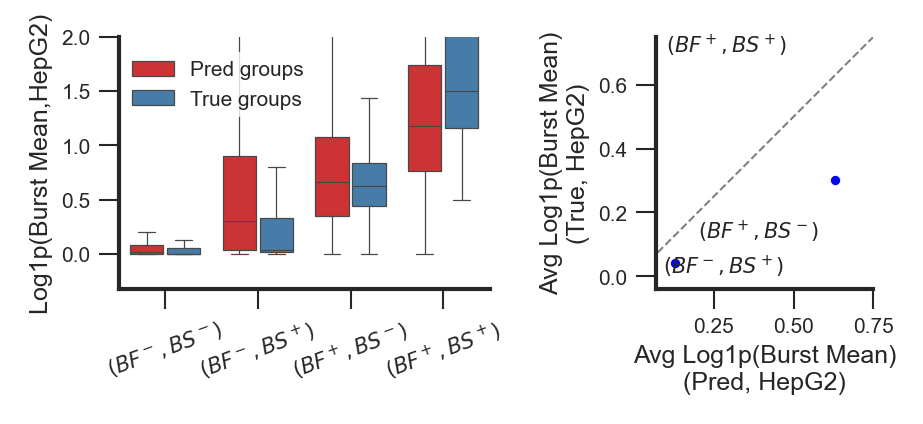

In [9]:
pred_marks = data[['pred_marks','mean']].groupby(by='pred_marks',as_index=False).mean()
pred_marks.columns = ['bins','mean']
labels_marks = data[['labels_marks','mean']].groupby(by='labels_marks',as_index=False).mean()
labels_marks.columns = ['bins','mean']

df_marks = pd.merge(pred_marks,labels_marks,on='bins')
r = stats.pearsonr(df_marks['mean_x'], df_marks['mean_y'])[0] * 100

fig, ax = plt.subplots(1, 2, constrained_layout=True,figsize=(8/2.54, 3.3/2.54))

sns.scatterplot(data=df_marks,x='mean_x',y='mean_y',s=6,color='blue',ax=ax[1])
ax[1].set_xlim(xmax=0.75)
ax[1].set_ylim(ymax=0.75)
ax[1].set_xlabel(f"Avg Log1p(Burst Mean)\n(Pred, {EIDS_TO_CELLTYPES[eid]})",fontsize=6)
ax[1].set_ylabel(f"Avg Log1p(Burst Mean)\n(True, {EIDS_TO_CELLTYPES[eid]})",fontsize=6)
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_aspect('equal')
ax[1].plot([0.001, 1], [0.001, 1], lw=0.5, color='gray', linestyle='--')

ax[1].annotate("$(BF^-,BS^-)$", xy=(0.01, 0.005), xytext=(-0.02,0.3), 
            arrowprops=dict(facecolor='black', edgecolor='black', 
                            linewidth=0.2, arrowstyle='->', 
                             shrinkA=0.1, lw=0.5, mutation_scale=5),fontsize=5)
ax[1].text(0.09,0.01,"$(BF^-,BS^+)$",fontdict={"size":5})
ax[1].text(0.2,0.12,"$(BF^+,BS^-)$",fontdict={"size":5})
ax[1].text(0.1,0.7,"$(BF^+,BS^+)$",fontdict={"size":5})


# 设置为 colorblind 调色板
sns.set_palette("colorblind")
sns.set_context("paper") 
order = pd.Index(["C1","C2","C3","C4"],name='marks')

df1 = data[['mean','pred_marks']]
df1.columns = ['mean','mark']
df1['type'] = 'Pred groups'

df2 = data[['mean','labels_marks']]
df2.columns = ['mean','mark']
df2['type'] = 'True groups'

df = pd.concat([df1,df2],axis=0)

sns.boxplot(data=df,y='mean',x='mark',hue='type',ax=ax[0],
            gap=0.1,width=0.8,fliersize=0,order=order,linewidth=0.3,
            palette="Set1")
ax[0].set_ylabel(f'Log1p(Burst Mean,{EIDS_TO_CELLTYPES[eid]})',fontsize=6)
ax[0].set_ylim(top=2)
ax[0].set_xticklabels(["$(BF^-,BS^-)$","$(BF^-,BS^+)$","$(BF^+,BS^-)$","$(BF^+,BS^+)$"],rotation=20,fontdict = {"size":5.5})  # ha参数用于设置水平对齐方式
ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].legend().remove()
ax[0].legend(loc='upper right', bbox_to_anchor=(0.55, 0.98),fontsize=5,edgecolor='none')  # Moves the legend outside the 

ax[0].set_xlabel('')


# plt.savefig('extra/figures/Figure2D.eps', format='eps', bbox_inches='tight')

plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


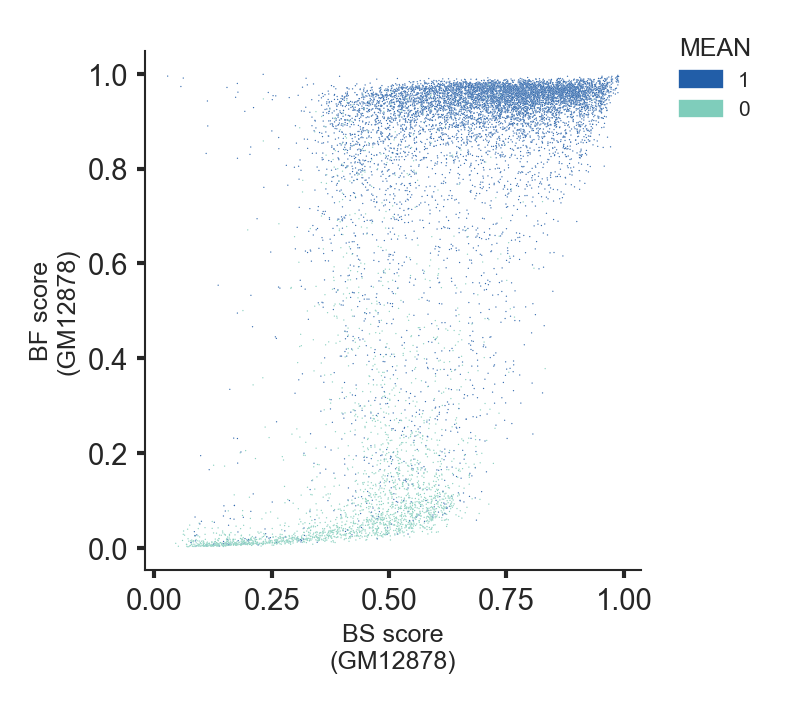

In [ ]:
eid='E116'
data = pd.read_csv(f'extra/results/{eid}_predictions_bs_bf.csv')
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"
seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

data = pd.merge(data,meta[['gene_id','mean','mean_label','sc_exp_label','cv_label']], how='inner',on='gene_id')
data = data[data['mean'] > 1e-3]
# Create the figure and axes
fig, ax = plt.subplots(figsize=(6/2.54, 6/2.54), dpi=300, facecolor='w', edgecolor='k')

palette = ["#7FCDBB", "#225EA8"]
# Create the scatter plot
scatter = sns.scatterplot(
    x=data['bs_label_score'],
    y=data['bf_label_score'],
    hue=data['mean_label'],  # Use 'hue' to map colors
    palette=palette,  # Specify the colormap
    s=0.1,  # Set marker size to 0.1
    legend=False,  # Disable the legend
    ax=ax  # Specify the axes to plot on
)

# 设置坐标轴
ax.set_ylabel(f"BF score\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
ax.set_xlabel(f"BS score\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)

# Add a colorbar
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color="#225EA8", label=1),
    mpatches.Patch(color="#7FCDBB", label=0),
]
ax.legend().remove()
# 添加 legend
fig.legend(handles=legend_patches, title="MEAN", loc="center left", bbox_to_anchor=(0.95, 0.9), title_fontsize=6,fontsize=5, frameon=False)


plt.savefig('extra/figures/Figure2C.eps', format='eps', bbox_inches='tight')

# Show the plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


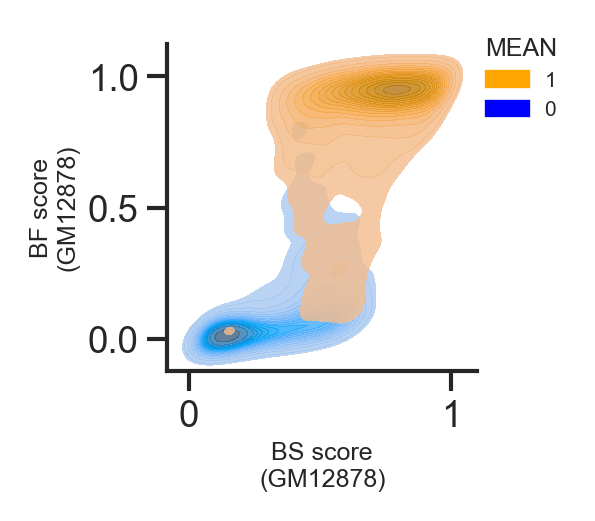

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
eid='E116'
data = pd.read_csv(f'extra/results/{eid}_predictions_bs_bf.csv')
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"
seed_everything(seed)
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.

data = pd.merge(data,meta[['gene_id','mean','mean_label','sc_exp_label']], how='inner',on='gene_id')
# 创建图形
fig, ax = plt.subplots(figsize=(4/2.54, 4/2.54), constrained_layout=True)

# 画密度图，分别绘制不同类别
ax = sns.kdeplot(
    data=data,
    x='bs_label_score',
    y='bf_label_score',
    levels=20,
    hue='sc_exp_label',
    fill=True,
    alpha=0.8,
    ax=ax
)

# 设置坐标轴
ax.set_ylabel(f"BF score\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)
ax.set_xlabel(f"BS score\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6)

# 显示 legend
import matplotlib.patches as mpatches

# 手动创建 legend
legend_patches = [
    mpatches.Patch(color="orange", label=1),
    mpatches.Patch(color="blue", label=0),
]
ax.legend().remove()
# 添加 legend
fig.legend(handles=legend_patches, title="MEAN", loc="center left", bbox_to_anchor=(0.95, 0.9), title_fontsize=6,fontsize=5, frameon=False)

# 保存和显示
plt.savefig('extra/figures/Figure2C.eps', format='eps', bbox_inches='tight')
plt.show()

# Burst Frequency Test Data AURoc

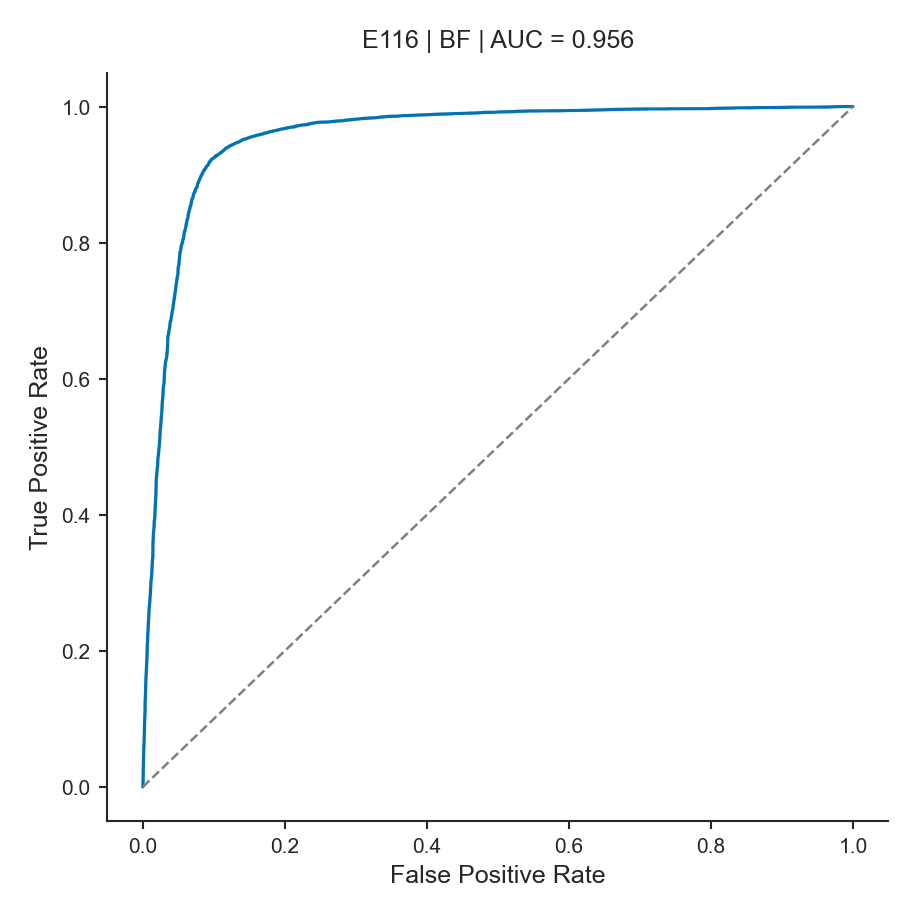

In [8]:
# 
eid = 'E116'
data = pd.read_csv(f'extra/results/{eid}_predictions_bs_bf.csv')
fpr, tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
sns.lineplot(x=fpr,y=tpr)
# plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | BF | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()


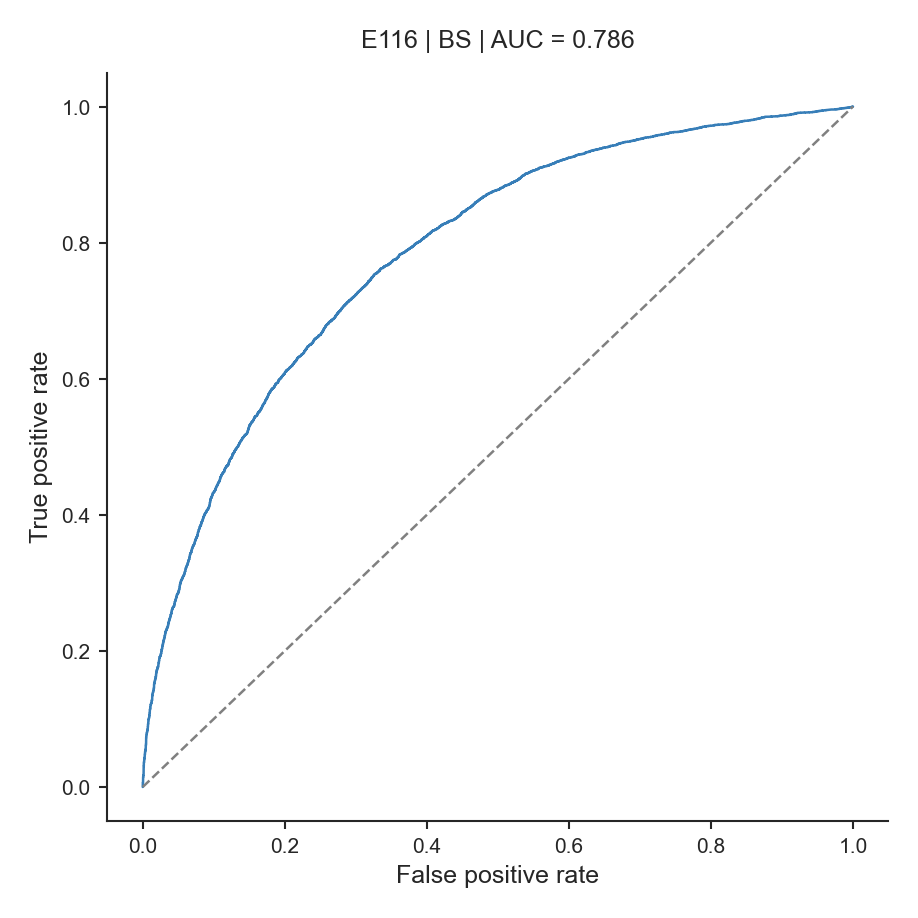

In [9]:
fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bs_label_label'],data['bs_label_pred'])

# 计算第二个模型的ROC曲线和F1分数
# 绘制两个模型的ROC曲线在一个图中
plt.plot(fpr, tpr, color='#377EB8', lw=0.6)
plt.plot([0, 1], [0, 1], lw=0.6, color='gray', linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
# plt.text(x=0.85,y=0.05, s=f'AUC = {roc_auc:.3f}',fontdict={'size':6})

plt.title(f"{eid} | BS | AUC = {roc_auc:.3f}")
#plt.savefig("ROC.png")
plt.show()

In [6]:
eid='E116'
data = pd.read_csv(f'extra/results/{eid}_predictions_cv_para.csv')
data_mean = pd.read_csv(f'extra/results/{eid}_predictions_mean_para.csv')
data_bs_bf = pd.read_csv(f'extra/results/{eid}_predictions_bs_bf.csv')
data2 = pd.merge(data,data_mean,on='gene_id')
data2 = pd.merge(data2,data_bs_bf,on='gene_id')
data2

,gene_id,cv_label_label,cv_label_score,cv_label_pred,fold_x,mean_label_label,mean_label_score,mean_label_pred,fold_y,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold
0,ENSG00000213977,1,0.768224,1,0,1,0.651105,1,0,1,0.326562,0,1,0.842578,1,0
1,ENSG00000067596,1,0.371509,0,0,1,0.998363,1,0,0,0.834472,1,1,0.926672,1,0
2,ENSG00000099901,0,0.346379,0,0,1,0.998892,1,0,1,0.926315,1,1,0.878627,1,0
3,ENSG00000171936,0,0.211065,0,0,0,0.002980,0,0,0,0.115504,0,0,0.005805,0,0
4,ENSG00000100012,0,0.318174,0,0,0,0.005766,0,0,0,0.264090,0,0,0.018792,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15482,ENSG00000175077,0,0.313672,0,3,0,0.006164,0,3,0,0.225953,0,0,0.010935,0,3
15483,ENSG00000172888,1,0.315854,0,3,1,0.998602,1,3,0,0.242782,0,1,0.960357,1,3
15484,ENSG00000178257,0,0.601906,1,3,0,0.020296,0,3,0,0.286109,0,0,0.031084,0,3
15485,ENSG00000141380,0,0.153866,0,3,1,0.999402,1,3,1,0.928136,1,1,0.986349,1,3


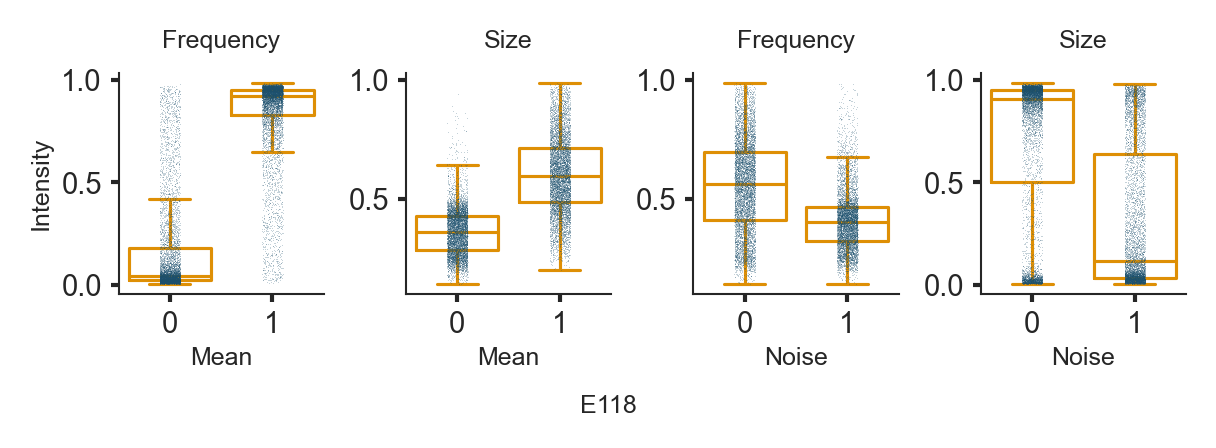

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns 

fig, ax = plt.subplots(1, 4, constrained_layout=True, figsize=(10/2.54, 3.5/2.54))

# Plot without the 'order' parameter
sns.stripplot(data=data2,x='mean_label_label',y='bf_label_score',s=0.1,ax=ax[0])
sns.boxplot(data=data2,x='mean_label_label',y='bf_label_score',fill=None,fliersize=0,ax=ax[0])
ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[0].set_ylabel('Intensity',fontsize=6)
ax[0].set_xlabel('Mean',fontsize=6)

sns.stripplot(data=data2,x='mean_label_label',y='bs_label_score',s=0.1,ax=ax[1])
sns.boxplot(data=data2,x='mean_label_label',y='bs_label_score',fill=None,fliersize=0,ax=ax[1])
ax[1].set_title('Size',fontsize=6,fontweight='regular')
ax[1].set_ylabel('')
ax[1].set_xlabel('Mean',fontsize=6)

sns.stripplot(data=data2,x='cv_label_label',y='bs_label_score',s=0.1,ax=ax[2])
sns.boxplot(data=data2,x='cv_label_label',y='bs_label_score',fill=None,fliersize=0,ax=ax[2])
ax[2].set_title('Frequency',fontsize=6,fontweight='regular')
ax[2].set_ylabel('')
ax[2].set_xlabel('Noise',fontsize=6)


sns.stripplot(data=data2,x='cv_label_label',y='bf_label_score',s=0.1,ax=ax[3])
sns.boxplot(data=data2,x='cv_label_label',y='bf_label_score',fill=None,fliersize=0,ax=ax[3])
ax[3].set_title('Size',fontsize=6,fontweight='regular')
ax[3].set_ylabel('')
ax[3].set_xlabel('Noise',fontsize=6)


fig.supxlabel(f'{eid}',fontsize=6)
# ax.tick_params(axis='both', labelsize=5, width=0.5, labelbottom=False, labelleft=True)
plt.show()

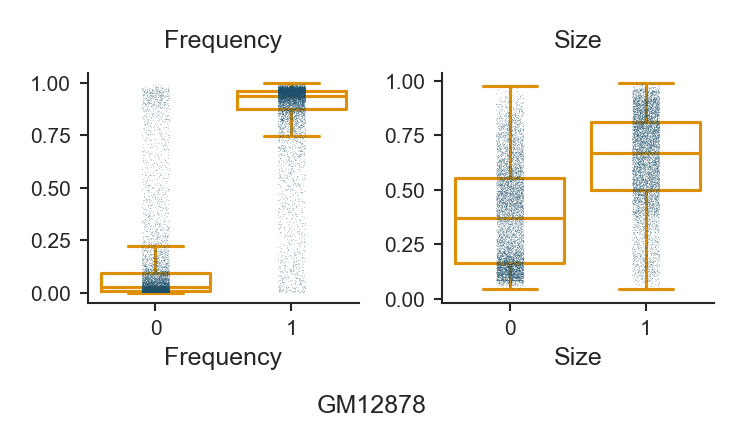

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(6/2.54, 3.5/2.54))


sns.stripplot(data=data2,x='bf_label_label',y='bf_label_score',s=0.1,ax=ax[0])
sns.boxplot(data=data2,x='bf_label_label',y='bf_label_score',fill=None,fliersize=0,ax=ax[0])
ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[0].set_ylabel('')
ax[0].set_xlabel('Frequency',fontsize=6)

sns.stripplot(data=data2,x='bs_label_label',y='bs_label_score',s=0.1,ax=ax[1])
sns.boxplot(data=data2,x='bs_label_label',y='bs_label_score',fill=None,fliersize=0,ax=ax[1])
ax[1].set_title('Size',fontsize=6,fontweight='regular')
ax[1].set_ylabel('')
ax[1].set_xlabel('Size',fontsize=6)




fig.supxlabel(f'{EIDS_TO_CELLTYPES[eid]}',fontsize=6)
# ax.tick_params(axis='both', labelsize=5, width=0.5, labelbottom=False, labelleft=True)
plt.show()

# Cell type specific

In [1]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
with open('extra/results/cell_type_specific_bs_bf_para.csv','w') as w:
    line = ['bs_auc','bf_auc','fold','eid']
    w.write('\t'.join(line) + '\n')
    for fold in [0,1,2,3]:
        for eid in eids:
            checkpoints = f'checkpoints/{eid}.{fold}.bs_bf_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            bs_auc = ckpt['bs_label_val_auc']
            bf_auc = ckpt['bf_label_val_auc']
            line = [str(bs_auc),str(bf_auc),str(fold), eid]
            w.write('\t'.join(line) + '\n')


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## cross-cell type prediction

       bs_auc     bf_auc  fold train_eid valid_eid
0   91.980111  87.671659     0      E116      E116
1   92.587652  89.681824     1      E116      E116
2   93.512275  88.291568     2      E116      E116
3   92.472308  88.746248     3      E116      E116
4   81.143617  85.858204     0      E116      E118
5   83.614747  86.388414     1      E116      E118
6   82.759169  83.661559     2      E116      E118
7   84.314818  86.143033     3      E116      E118
8   79.710316  91.270737     0      E116      E003
9   79.143523  90.741736     1      E116      E003
10  78.961035  91.409285     2      E116      E003
11  78.770272  91.660290     3      E116      E003
12  91.482483  83.644268     0      E118      E116
13  91.779898  87.921715     1      E118      E116
14  92.658365  86.567556     2      E118      E116
15  91.851342  86.885690     3      E118      E116
16  82.355508  88.022455     0      E118      E118
17  84.159470  88.299561     1      E118      E118
18  84.197164  88.267201     2 

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32421/2224054326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32421/2224054326.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]}(train) -> {EIDS_TO_CELLTYPES[valid_eid]}(val)" for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32421/2224054326.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=da

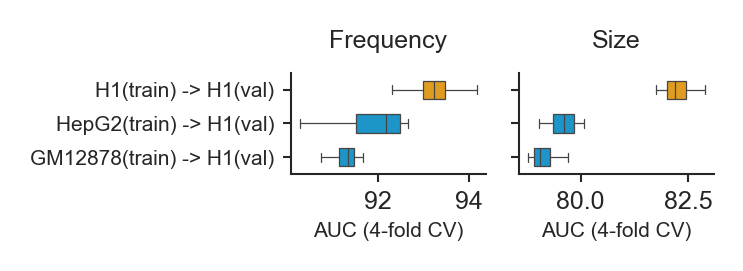

In [34]:
data = pd.read_csv("extra/results/cross_cell_type_bs_bf_para.csv",sep='\t')
print(data)
order = pd.Index(["E003","E118","E116"],name='marks')
sns.set_palette("colorblind")
valid_eid = 'E003'
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(6/2.54, 2/2.54))


sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.1,width=0.6,palette=['orange',(0/255, 161/255, 229/255),(0/255, 161/255, 229/255)],ax=ax[0])

ax[0].set_ylabel("",fontsize=6)
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]}(train) -> {EIDS_TO_CELLTYPES[valid_eid]}(val)" for eid in order])
ax[0].set_xlabel("AUC (4-fold CV)",fontsize=5)
ax[0].set_title('Frequency',fontsize=6)

sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bs_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.1,width=0.6,palette=['orange',(0/255, 161/255, 229/255),(0/255, 161/255, 229/255)],ax=ax[1])

ax[1].set_ylabel("",fontsize=6)
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_yticklabels([f"" for eid in order])
ax[1].set_xlabel("AUC (4-fold CV)",fontsize=5)
ax[1].set_title('Size',fontsize=6)


# plt.savefig('extra/figures/v5/Figure2G.eps', format='eps', bbox_inches='tight')


plt.show()

In [44]:
for valid_eid in  ['E116','E118','E003']:
    for train_eid in ['E116','E118','E003']:
        auc = data[(data['valid_eid']==valid_eid) and (data['train_eid']==train_eid)]['bf_auc']


,bs_auc,bf_auc,fold,train_eid,valid_eid
4,66.025430,91.051809,0,E116,E118
5,67.614153,92.081948,1,E116,E118
6,67.306948,92.077784,2,E116,E118
7,66.639910,93.003354,3,E116,E118
16,67.655729,93.440384,0,E118,E118
17,69.644339,93.691775,1,E118,E118
18,69.259194,93.891992,2,E118,E118
19,68.754251,94.475844,3,E118,E118
28,60.547819,91.672226,0,E003,E118
29,64.592409,93.164478,1,E003,E118


# One-feature ablation

### BS one-feature ablation

In [5]:
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
predictions = []
target = 'bs'
with open(f'extra/results/one_feature_indicators_{target}_para.csv','w') as w:
    line = ['eid','keep_mark','fold','auc']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:
        for fold in [0,1,2,3]:
            for keep_mark in MARKS:
                remove_marks = deepcopy(MARKS)
                remove_marks.remove(keep_mark)
    
                checkpoints = f"checkpoints/{eid}.remove_{'_'.join(remove_marks)}.{fold}.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f"{target}_label_val_auc"]
                line = [eid,keep_mark,str(fold),str(auc)]
                w.write(','.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.bs_bf_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt[f'{target}_label_val_auc']
            line = [eid,'all_marks',str(fold),str(auc)]
            w.write(','.join(line) + '\n')


data = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data

,eid,keep_mark,fold,auc
0,E116,H3K4me1,0,88.377370
1,E116,H3K4me3,0,89.728806
2,E116,H3K9me3,0,65.395460
3,E116,H3K27me3,0,79.661403
4,E116,H3K36me3,0,88.539167
...,...,...,...,...
91,E003,H3K27me3,3,71.760579
92,E003,H3K36me3,3,75.032227
93,E003,H3K27ac,3,78.577288
94,E003,H3K9ac,3,79.220101


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_30155/2844459209.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


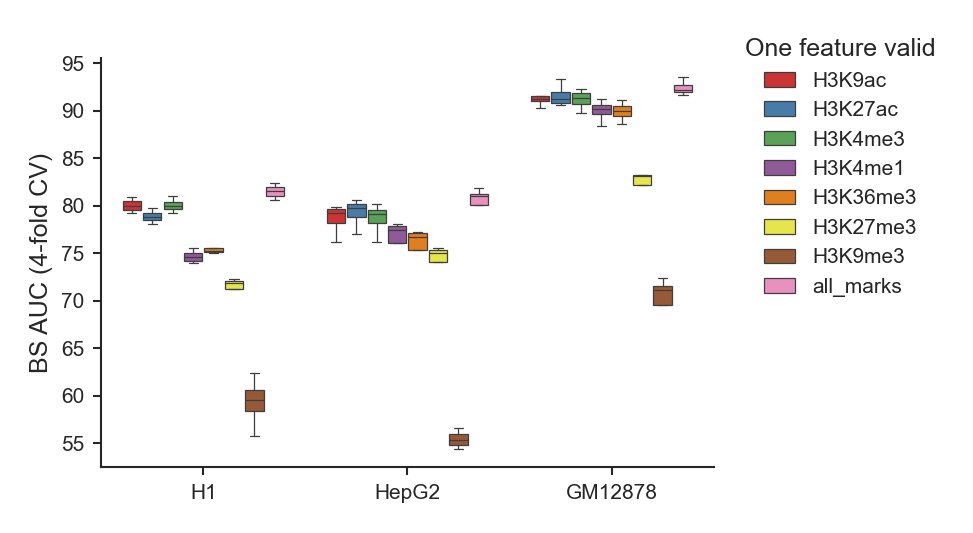

In [6]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))


hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3",'all_marks'],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BS AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

### BF one-feature ablation

In [7]:
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
predictions = []
target = 'bf'
with open(f'extra/results/one_feature_indicators_{target}_para.csv','w') as w:
    line = ['eid','keep_mark','fold','auc']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:
        for keep_mark in MARKS:
            remove_marks = deepcopy(MARKS)
            remove_marks.remove(keep_mark)
            
            for fold in [0,1,2,3]:
                checkpoints = f"checkpoints/{eid}.remove_{'_'.join(remove_marks)}.{fold}.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f"{target}_label_val_auc"]
                line = [eid,keep_mark,str(fold),str(auc)]
                w.write(','.join(line) + '\n')

data = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data

,eid,keep_mark,fold,auc
0,E116,H3K4me1,0,85.240056
1,E116,H3K4me1,1,87.198100
2,E116,H3K4me1,2,86.492481
3,E116,H3K4me1,3,86.690382
4,E116,H3K4me3,0,88.105995
...,...,...,...,...
79,E003,H3K27ac,3,89.991585
80,E003,H3K9ac,0,90.639236
81,E003,H3K9ac,1,91.044967
82,E003,H3K9ac,2,91.590807


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_30155/1701844389.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


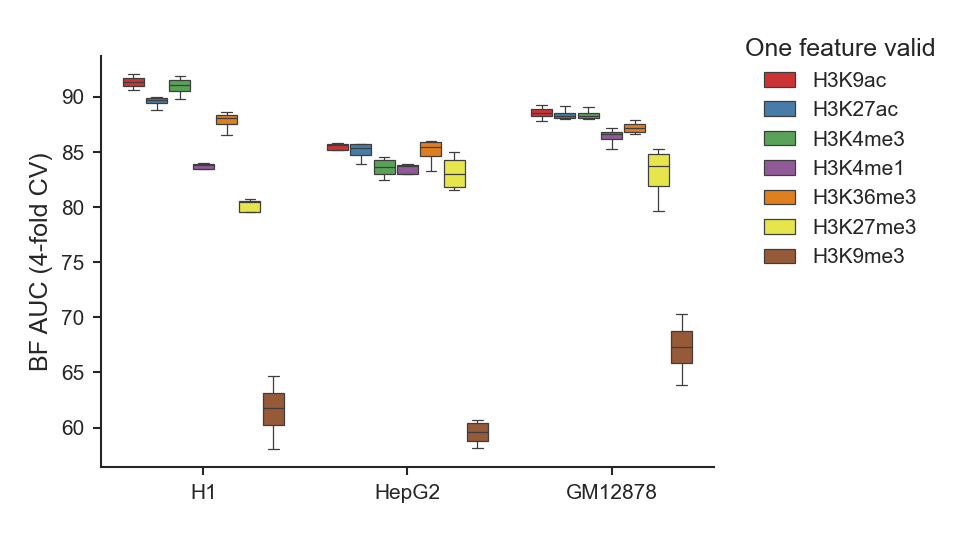

In [8]:

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BF AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

In [14]:
predictions = []
target = 'bs'
with open(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv','w') as w:
    line = ['eid','keep_mark','fold','auc']
    w.write(','.join(line) + '\n')
    for eid in ["E116","E118","E003"]:
        for keep_mark in MARKS:
            remove_marks = deepcopy(MARKS)
            # remove_marks.remove(keep_mark)
            
            for fold in [0,1,2,3]:
                checkpoints = f"checkpoints/{eid}.keep_{keep_mark}.{fold}.distance_1000.bs_bf_para.model.pt"
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f"{target}_label_val_auc"]
                line = [eid,keep_mark,str(fold),str(auc)]
                w.write(','.join(line) + '\n')




/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_30155/1103062719.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


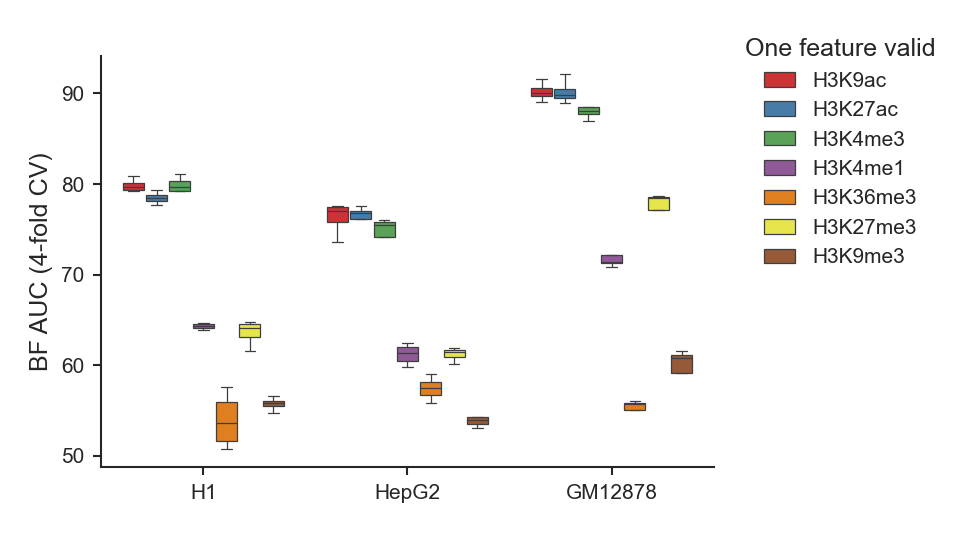

In [15]:
data = pd.read_csv(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv')
data

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BF AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

    eid keep_mark  fold      auc_x      auc_y  increase
0  E116   H3K4me1     0  88.377370  71.413915  0.237537
1  E116   H3K4me3     0  89.728806  86.969380  0.031729
2  E116   H3K9me3     0  65.395460  60.537821  0.080241
3  E116  H3K27me3     0  79.661403  73.617774  0.082095
4  E116  H3K36me3     0  88.539167  55.760612  0.587844


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_30155/1568454104.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


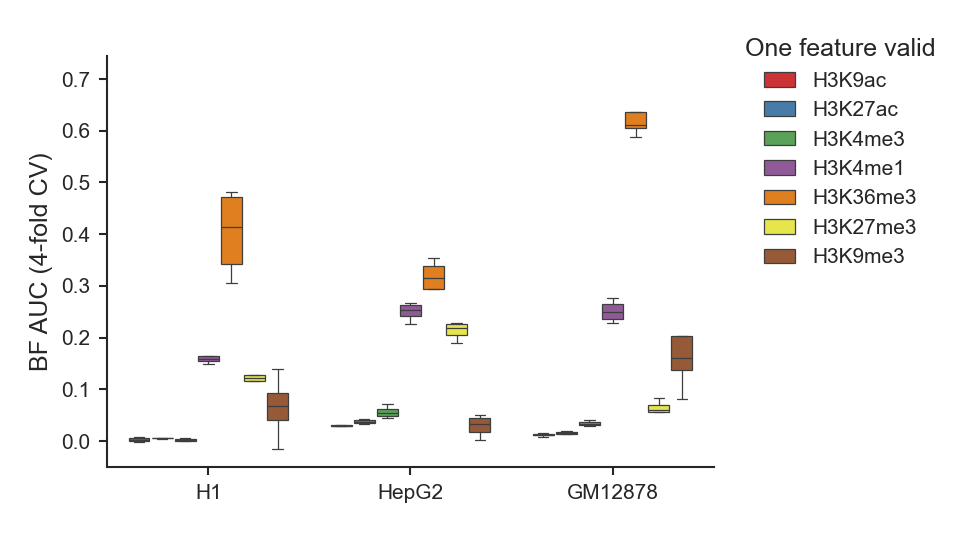

In [16]:
target = 'bs'
data_1 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv')
data = pd.merge(data_1,data_2,on=['eid','keep_mark','fold'])
data['increase'] = data['auc_x']/data['auc_y'] - 1

print(data.head())
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

hue_order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='increase',x='eid',hue='keep_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BF AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
plt.show()

  keep_mark  fold  increase
0   H3K27ac     0  0.013197
1   H3K27ac     1  0.013721
2   H3K27ac     2  0.011934
3   H3K27ac     3  0.010555
4  H3K27me3     0  0.161570
5  H3K27me3     1  0.170649
6  H3K27me3     2  0.183551
7  H3K27me3     3  0.182518
8  H3K36me3     0  0.486290
9  H3K36me3     1  0.629363
  keep_mark  fold  increase
0   H3K27ac     0  0.020017
1   H3K27ac     1  0.018560
2   H3K27ac     2  0.020383
3   H3K27ac     3  0.019000
4  H3K27me3     0  0.133033
5  H3K27me3     1  0.128173
6  H3K27me3     2  0.132659
7  H3K27me3     3  0.139814
8  H3K36me3     0  0.396023
9  H3K36me3     1  0.461348


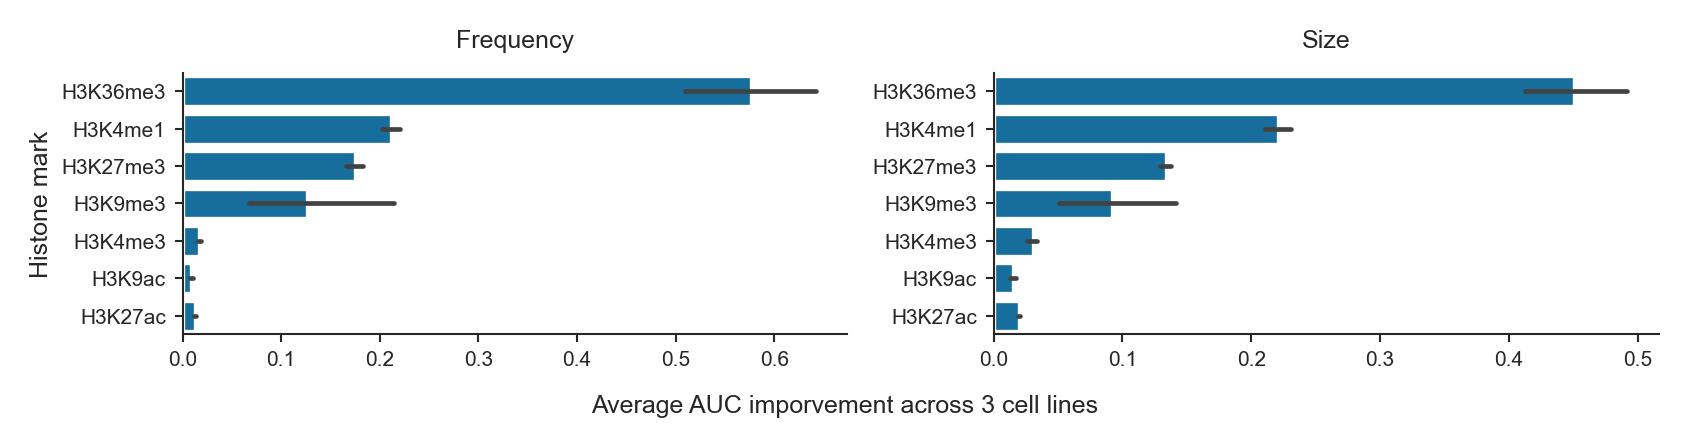

In [17]:
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(14/2.54, 3.5/2.54))

target = 'bf'
data_1 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv')
data = pd.merge(data_1,data_2,on=['eid','keep_mark','fold'])
data['increase'] = data['auc_x']/data['auc_y'] - 1
data = data[['keep_mark','fold','increase']].groupby(by=['keep_mark','fold'],as_index=False).agg('mean')
print(data.head(10))
order = pd.Index(["H3K36me3","H3K4me1","H3K27me3","H3K9me3","H3K4me3","H3K9ac","H3K27ac"],name='marks')
sns.barplot(data=data,x='increase',y='keep_mark',order=order,ax=ax[0])

ax[0].tick_params(axis='both', labelsize=5,width=0.5)
ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[0].set_ylabel('Histone mark',fontsize=6)
ax[0].set_xlabel('')

target = 'bs'
data_1 = pd.read_csv(f'extra/results/one_feature_indicators_{target}_para.csv')
data_2 = pd.read_csv(f'extra/results/one_feature_indicators_distance_1000_{target}_para.csv')
data = pd.merge(data_1,data_2,on=['eid','keep_mark','fold'])
data['increase'] = data['auc_x']/data['auc_y'] - 1
data = data[['keep_mark','fold','increase']].groupby(by=['keep_mark','fold'],as_index=False).agg('mean')
print(data.head(10))
order = pd.Index(["H3K36me3","H3K4me1","H3K27me3","H3K9me3","H3K4me3","H3K9ac","H3K27ac"],name='marks')
sns.barplot(data=data,x='increase',y='keep_mark',order=order,ax=ax[1])
ax[1].tick_params(axis='both', labelsize=5,width=0.5)
ax[1].set_title('Size',fontsize=6,fontweight='regular')

ax[1].set_ylabel('',fontsize=6)
ax[1].set_xlabel('')
fig.supxlabel('Average AUC imporvement across 3 cell lines',fontsize=6,fontweight='regular')

plt.show()
# ax = sns.boxplot(data=data,y='increase',x='eid',hue='keep_mark',
#                  gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
#                  palette="Set1")
# ax.tick_params(axis='both', labelsize=5,width=0.5)
# plt.ylabel(f'BF AUC (4-fold CV)',fontsize=6)
# # ax.set_ylim(top=4)
# ax.set_xlabel('')
# ax.legend().remove()
# ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.show()

# Abelation Experiments

### BS Abelation Experiments

In [18]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
target = 'bs'
with open(f'extra/results/ablation_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write('\t'.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                checkpoints = f'checkpoints/{eid}.remove_{remove_mark}.{fold}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"remove_{remove_mark}",str(fold), eid]
                w.write('\t'.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.bs_bf_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt[f'{target}_label_val_auc']
            line = [str(auc),'all_marks',str(fold),eid]
            w.write('\t'.join(line) + '\n')       



/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_30155/1763914470.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


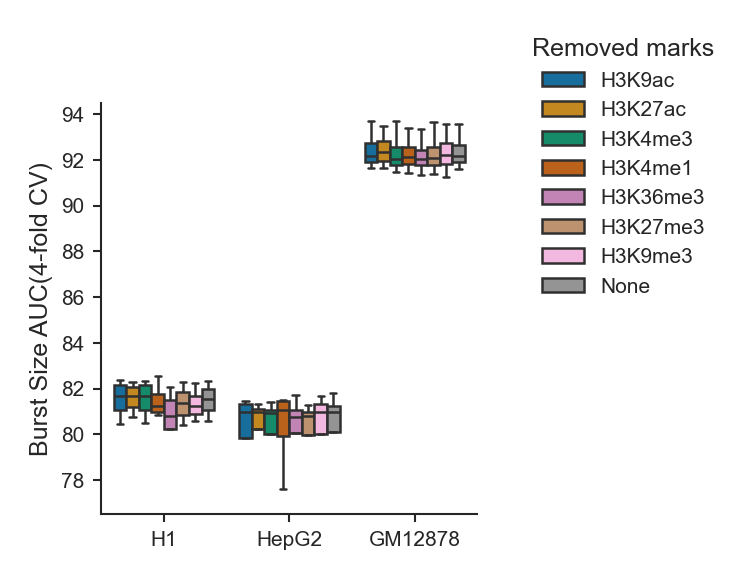

In [19]:
data =  pd.read_csv('extra/results/ablation_bs_para.csv',sep='\t')
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))

order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')

sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax,order=order,hue_order=hue_order)
ax.legend().remove()  # Moves the legend outside the plot
ax.set_ylabel('Burst Size AUC(4-fold CV)')
ax.set_xlabel('')

handles, labels = ax.get_legend_handles_labels()
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.15) , title='Removed marks', fontsize=5,ncol=1,edgecolor='none',title_fontsize=6)

ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
plt.legend().remove()
# plt.savefig('extra/figures/Figure4_BS.eps', format='eps', bbox_inches='tight')

plt.show()

### BF Abelation Experiments

In [20]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
target = 'bf'
with open(f'extra/results/ablation_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write('\t'.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                checkpoints = f'checkpoints/{eid}.remove_{remove_mark}.{fold}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"remove_{remove_mark}",str(fold), eid]
                w.write('\t'.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.bs_bf_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt[f'{target}_label_val_auc']
            line = [str(auc),'all_marks',str(fold),eid]
            w.write('\t'.join(line) + '\n')       

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_30155/536678153.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


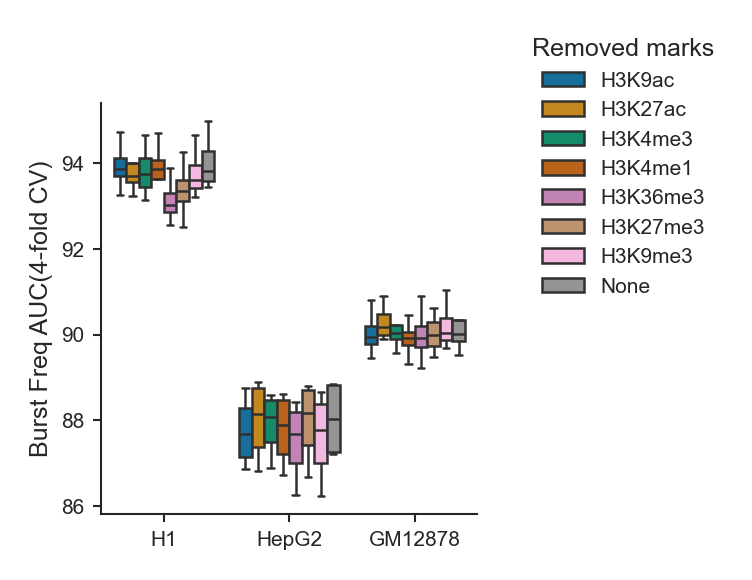

In [21]:
data =  pd.read_csv(f'extra/results/ablation_{target}_para.csv',sep='\t')
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))

order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')

sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax,order=order,hue_order=hue_order)
ax.legend().remove()  # Moves the legend outside the plot
ax.set_ylabel('Burst Freq AUC(4-fold CV)')
ax.set_xlabel('')

handles, labels = ax.get_legend_handles_labels()
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.15) , title='Removed marks', fontsize=5,ncol=1,edgecolor='none',title_fontsize=6)

ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
plt.legend().remove()

plt.show()

# Distance Importance

## BS distance expriments

In [22]:
import torch 
from src.utils.constants import DEVICE
target='bs'
eids = ['E003','E116','E118']
with open(f'extra/results/distance_{target}_para.csv','w') as w:
    line = ['auc','fold','distance','eid']
    w.write('\t'.join(line) + '\n')
    for _eid in eids:
        for distance in [1000, 2000, 5000,10000,20000,40000]:
            for fold in [0,1,2,3]:

                checkpoints = f'checkpoints/{_eid}.{fold}.{distance}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                cv_auc = ckpt[f'{target}_label_val_auc']
                line = [str(cv_auc),str(fold),str(distance), _eid]
                w.write('\t'.join(line) + '\n')
        

In [23]:
data = pd.read_csv(f'extra/results/distance_{target}_para.csv',sep='\t')
data


,auc,fold,distance,eid
0,81.243001,0,1000,E003
1,80.164379,1,1000,E003
2,82.214290,2,1000,E003
3,80.397771,3,1000,E003
4,81.279022,0,2000,E003
...,...,...,...,...
67,81.637440,3,20000,E118
68,77.644452,0,40000,E118
69,80.921960,1,40000,E118
70,81.061807,2,40000,E118


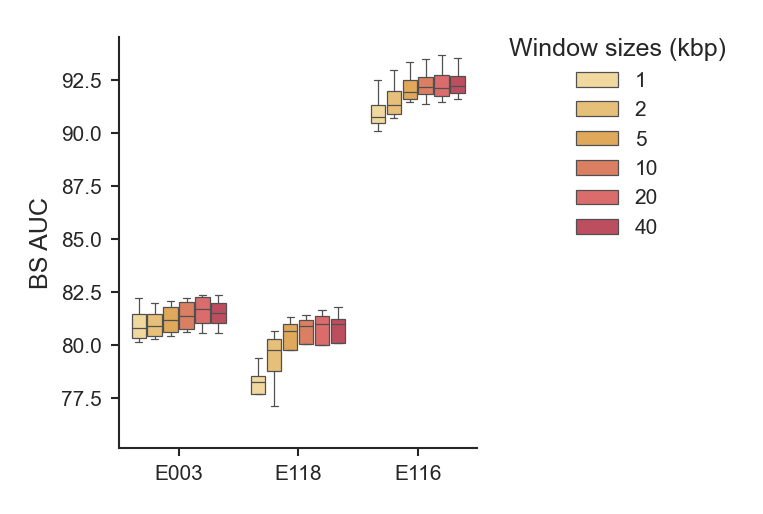

In [24]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))


ax = sns.boxplot(data=data,x='eid',y='auc',hue='distance',fliersize=0,ax=ax,linewidth=0.3,order=order,
             gap=0.1,width=0.8,palette=[(253/255, 222/255, 145/255),(249/255, 196/255,101/255), (246/255, 172/255, 68/255),( 239/255, 116/255, 79/255), (237/255, 91/255,88/255), (207/255, 59/255, 82/255)],)


# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()
ax.set_xlabel('')
ax.set_ylabel('BS AUC')
handles, labels = ax.get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]

fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.0, 1.01) , title='Window sizes (kbp)', fontsize=5,title_fontsize=6,ncol=1,edgecolor='none')

plt.show()

## BF distance expriments

In [25]:
import torch 
from src.utils.constants import DEVICE
target='bf'
eids = ['E003','E118','E116']
with open(f'extra/results/distance_{target}_para.csv','w') as w:
    line = ['auc','fold','distance','eid']
    w.write('\t'.join(line) + '\n')
    for _eid in eids:
        for distance in [1000, 2000, 5000,10000,20000,40000]:
            for fold in [0,1,2,3]:

                checkpoints = f'checkpoints/{_eid}.{fold}.{distance}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                cv_auc = ckpt[f'{target}_label_val_auc']
                line = [str(cv_auc),str(fold),str(distance), _eid]
                w.write('\t'.join(line) + '\n')
        

In [26]:
data = pd.read_csv(f'extra/results/distance_{target}_para.csv',sep='\t')
data


,auc,fold,distance,eid
0,91.698131,0,1000,E003
1,92.074619,1,1000,E003
2,92.837569,2,1000,E003
3,93.039340,3,1000,E003
4,92.479792,0,2000,E003
...,...,...,...,...
67,90.238139,3,20000,E116
68,89.963564,0,40000,E116
69,90.994361,1,40000,E116
70,89.529388,2,40000,E116


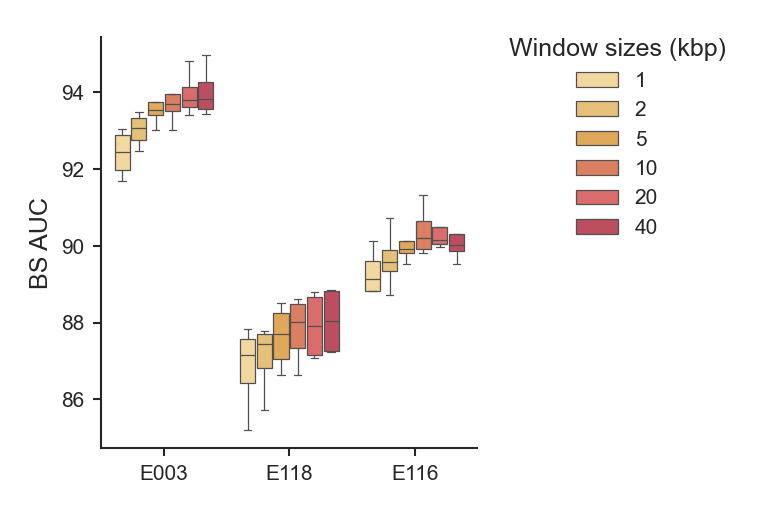

In [27]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(4/2.54, 4/2.54))

sns.boxplot(data=data,x='eid',y='auc',hue='distance',fliersize=0,ax=ax,linewidth=0.3,order=order,
             gap=0.1,width=0.8,palette=[(253/255, 222/255, 145/255),(249/255, 196/255,101/255), (246/255, 172/255, 68/255),( 239/255, 116/255, 79/255), (237/255, 91/255,88/255), (207/255, 59/255, 82/255)],)


# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()
ax.set_xlabel('')
ax.set_ylabel('BS AUC')
handles, labels = ax.get_legend_handles_labels()
labels = ["1","2","5","10","20","40"]

fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.0, 1.01) , title='Window sizes (kbp)', fontsize=5,title_fontsize=6,ncol=1,edgecolor='none')

plt.show()

## ACC compared

In [42]:
data = pd.read_csv("extra/results/distance_region_predictions_bs_bf.csv")
eid = 'E116'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
# data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]
# data_1kb = data_1kb[['gene_id','bf_label_pred','bf_label_score','window_size']]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
# data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]
# data_40kb = data_40kb[['gene_id','bf_label_pred','bf_label_score','window_size']]

data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')

def class_type(row):
    if row['bf_label_pred_x']==1 and row['bf_label_pred_y']==1:
        return 'c1'
    elif row['bf_label_pred_x']==0 and row['bf_label_pred_y']==1:
        return 'c2'
    elif row['bf_label_pred_x']==1 and row['bf_label_pred_y']==0:
        return 'c3'
    else:
        return 'c4'
    
def class_type(row):
    if row['bf_label_pred_x']==1 and row['bf_label_pred_y']==1:
        return 'c1'
    elif row['bf_label_pred_x']==0 and row['bf_label_pred_y']==1:
        return 'c2'
    elif row['bf_label_pred_x']==1 and row['bf_label_pred_y']==0:
        return 'c3'
    else:
        return 'c4'

data_merge['bin'] = data_merge.apply(lambda row: class_type(row),axis=1)
data_merge.groupby(by='bin').count()


,gene_id,bs_label_label_x,bs_label_score_x,bs_label_pred_x,bf_label_label_x,bf_label_score_x,bf_label_pred_x,eid_x,fold_x,window_size_x,bs_label_label_y,bs_label_score_y,bs_label_pred_y,bf_label_label_y,bf_label_score_y,bf_label_pred_y,eid_y,fold_y,window_size_y
bin,,,,,,,,,,,,,,,,,,,
c1,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352,5352
c2,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759,1759
c3,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24
c4,548,548,548,548,548,548,548,548,548,548,548,548,548,548,548,548,548,548,548


                gene_id  bs_label_label  bs_label_score  bs_label_pred  \
92720   ENSG00000108829               1        0.271231              0   
92770   ENSG00000167302               0        0.241395              0   
92888   ENSG00000107164               0        0.256704              0   
92889   ENSG00000105085               0        0.254480              0   
93098   ENSG00000169021               1        0.281610              0   
...                 ...             ...             ...            ...   
106269  ENSG00000170871               0        0.245665              0   
106303  ENSG00000163754               0        0.218483              0   
106316  ENSG00000124214               1        0.224277              0   
106331  ENSG00000124171               1        0.229310              0   
106349  ENSG00000140941               1        0.230443              0   

        bf_label_label  bf_label_score  bf_label_pred   eid  fold  window_size  
92720                1        

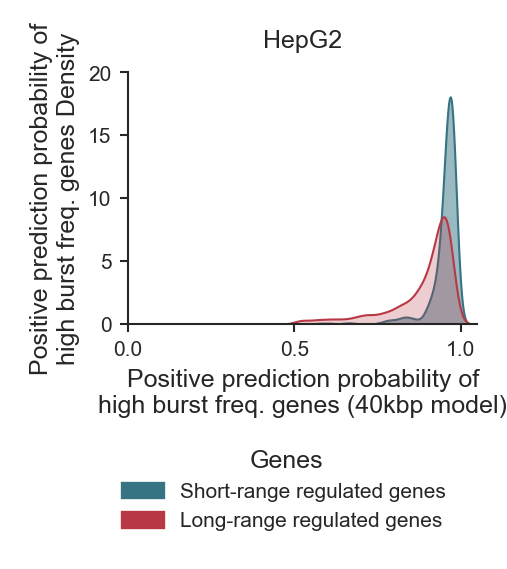

In [6]:
data = pd.read_csv("extra/results/distance_region_predictions_bs_bf.csv")
palette = ["#B83945","#377483"]
eid = 'E118'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]

# data_merge = pd.merge(data_1kb,data_40kb,on='gene_id')
print(data_1kb)
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(4/2.54, 3.5/2.54))

sns.kdeplot(data_40kb[data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5,alpha=0.5, color=palette[1])
sns.kdeplot(data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]['bf_label_score'],fill=True,linewidth=0.5, color=palette[0])

ax.set_xlabel('Positive prediction probability of\nhigh burst freq. genes (40kbp model)',fontsize=6)
ax.set_ylabel('Positive prediction probability of\nhigh burst freq. genes Density',fontsize=6)
ax.set_yticks([i for i in range(0,21,5)])
ax.set_xticks([i/10 for i in range(0,11,5)])
ax.set_xlim(0,1.05)

ax.set_title(f'{EIDS_TO_CELLTYPES[eid]}')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[1], label="Short-range regulated genes "),
    mpatches.Patch(color=palette[0], label="Long-range regulated genes"),
]
fig.legend(handles=legend_patches, title="Genes", loc="upper center", bbox_to_anchor=(0.57, -0.0), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

# plt.savefig(f'extra/figures/v5/Supplementary_figure3A_1.eps', format='eps', bbox_inches='tight')


plt.show()


In [4]:
data = pd.read_csv("extra/results/distance_region_predictions_bs_bf.csv")

eid = 'E118'
data_1kb = data[(data['eid']==eid) & (data['window_size']==1000) & (data['bf_label_label']==1)]
data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_label']==1)]
data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]
data_40kb = data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]


gene_ids_1kbp = data_1kb['gene_id']
gene_ids_40kbp = data_40kb['gene_id']


In [ ]:
from scripts.utils import bin_and_padding

def get_mark_signals(gene_ids,eid, marks):
    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"
    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )
    meta_infos = list(meta[meta['gene_id'].isin(gene_ids)][['gene_id','strand']].values)
    mark_idx = [_idx for _idx,mark in  enumerate(marks) if mark in  MARKS]
    signals = np.array([bin_and_padding(np.load(os.path.join(npy_dir,eid,f'regions/{gene_id}.npy')),strand=strand)[0][mark_idx] for gene_id, strand in meta_infos])
    return signals

marks = MARKS
mark_signals_1kbp = get_mark_signals(gene_ids_1kbp,eid,marks)
with open(f"extra/results/{eid}_mark_signals_1kbp.npy", 'wb') as f:
    np.save(f,mark_signals_1kbp)

mark_signals_1kbp = mark_signals_1kbp[...,40]
mark_signals_40kbp = get_mark_signals(gene_ids_40kbp,eid,marks)
with open(f"extra/results/{eid}mark_signals_40kbp.npy", 'wb') as f:
    np.save(f,mark_signals_40kbp)
mark_signals_40kbp = mark_signals_40kbp[...,40]



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


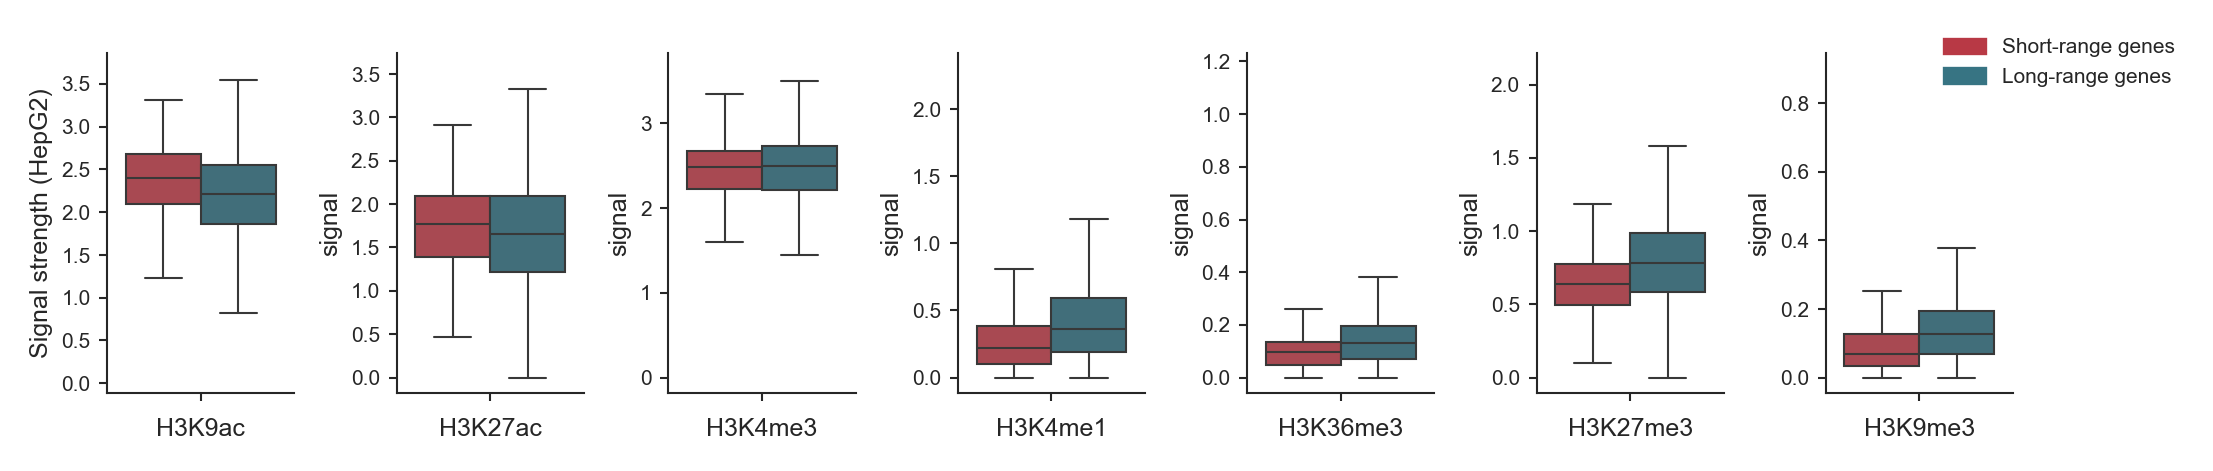

In [14]:

eid = 'E118'
palette = ["#B83945","#377483"]
mark_signals_1kbp = np.load(f"extra/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,39:41]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,39:41]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']


fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(17/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette,
            fliersize=0,
            linewidth=0.5,            
            ax=ax[idx % 7],
        )
    ax[idx % 7].legend().remove()

    # ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    ax[idx % 7].set_xlabel(mark, fontsize=6,fontweight='regular')
    # Set the xlabel for each subplot

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='Short-range genes'),
    mpatches.Patch(color=palette[1], label='Long-range genes'),
]
fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

# fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
ax[0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)

plt.savefig(f'extra/figures/v5/Supplementary_figure4H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


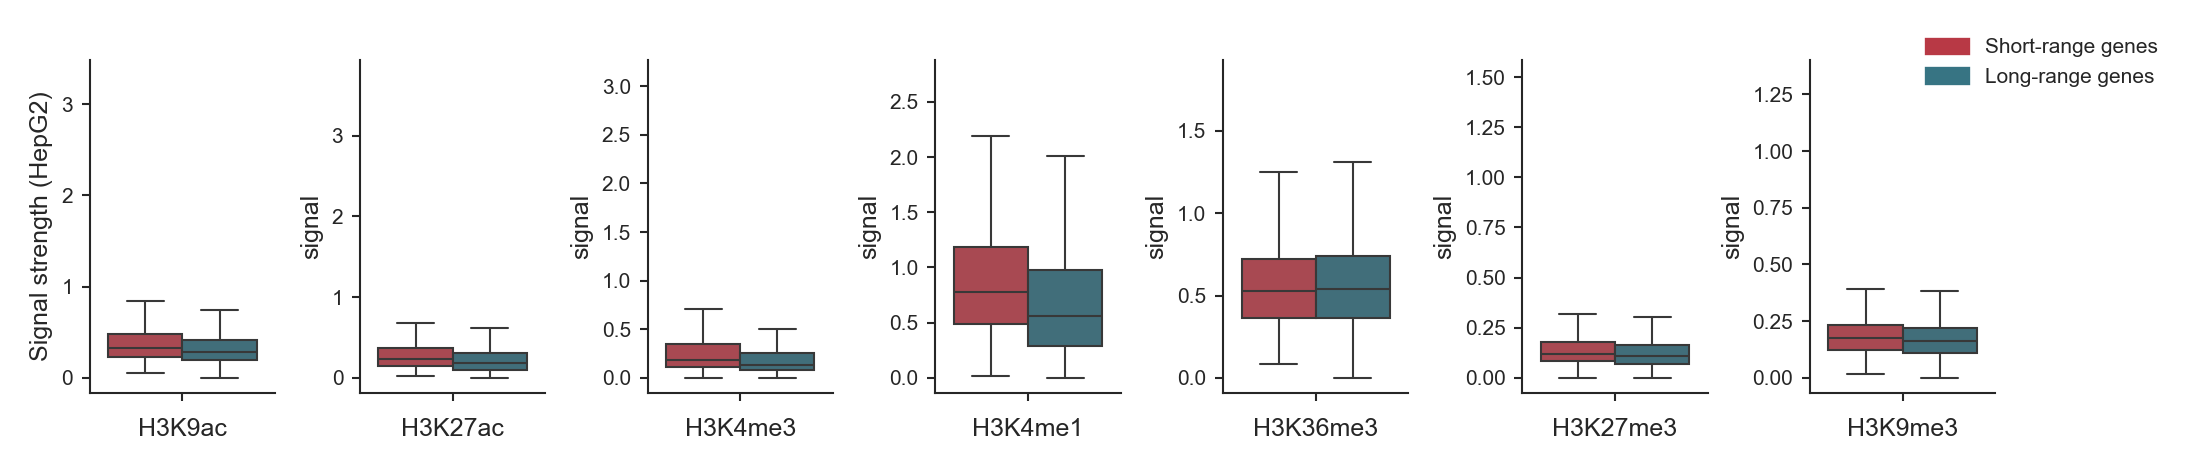

In [9]:

eid = 'E118'
palette = ["#B83945","#377483"]
mark_signals_1kbp = np.load(f"extra/results/{eid}_mark_signals_1kbp.npy")
mark_signals_1kbp = mark_signals_1kbp[...,48:52]
mark_signals_1kbp = np.mean(mark_signals_1kbp,axis=-1)

mark_signals_40kbp = np.load(f"extra/results/{eid}mark_signals_40kbp.npy")
mark_signals_40kbp = mark_signals_40kbp[...,48:52]
mark_signals_40kbp = np.mean(mark_signals_40kbp,axis=-1)

MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']


fig, ax = plt.subplots(1, 7, constrained_layout=True, figsize=(17/2.54, 3.5/2.54))

# Loop through the plots and plot the data without labels for legends
for idx, mark in enumerate(yticks):
    _idx = MARKS.index(mark)
    # Plot the data without 'label' argument to avoid legends in subplots
    data_1kbp = pd.DataFrame({'signal':mark_signals_1kbp[...,_idx],'distance':'1kbp'})
    data_40kbp = pd.DataFrame({'signal':mark_signals_40kbp[...,_idx],'distance':'40kbp'})
    data = pd.concat([data_1kbp,data_40kbp],axis=0)
    sns.boxplot(data=data, y='signal',hue='distance',
                palette=palette,
            fliersize=0,
            linewidth=0.5,            
            ax=ax[idx % 7],
        )
    ax[idx % 7].legend().remove()

    # ax[idx % 7].set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

    ax[idx % 7].set_xlabel(mark, fontsize=6,fontweight='regular')
    # Set the xlabel for each subplot

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='Short-range genes'),
    mpatches.Patch(color=palette[1], label='Long-range genes'),
]
fig.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(0.95, 1.05) , title_fontsize=6,fontsize=5,ncol=1,edgecolor='none')

# fig.supxlabel("Distance to TSS (kbp)",fontsize=6)
ax[0].set_ylabel(f"Signal strength ({EIDS_TO_CELLTYPES[eid]})",fontsize=6)

# plt.savefig(f'extra/figures/v5/Supplementary_figure4H_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()


In [61]:
data_1kb

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,eid,fold,window_size
20,ENSG00000174886,1,0.255627,0,1,0.576856,1,E116,0,1000
26,ENSG00000106799,0,0.258166,0,1,0.674178,1,E116,0,1000
43,ENSG00000095380,1,0.243871,0,1,0.548600,1,E116,0,1000
48,ENSG00000100084,0,0.236163,0,1,0.535770,1,E116,0,1000
55,ENSG00000126261,1,0.259538,0,1,0.588710,1,E116,0,1000
...,...,...,...,...,...,...,...,...,...,...
15402,ENSG00000172939,1,0.355596,0,1,0.864786,1,E116,3,1000
15408,ENSG00000085978,0,0.365588,0,1,0.835590,1,E116,3,1000
15411,ENSG00000101079,0,0.422203,0,1,0.646698,1,E116,3,1000
15415,ENSG00000152492,1,0.405823,0,1,0.610399,1,E116,3,1000


## Single mark distance predictions

In [ ]:
data = pd.read_csv('extra/results/distance_region_predictions_bs_bf.csv')


# Feature Importance

In [4]:
import torch
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from captum.attr import DeepLift
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from scripts.analysis.utils import plot_heatmap

from src.model.constants import get_config
# from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E118'
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]

    checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"

    meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]

    print(len(train_genes), len(val_genes))

    val_dataset = DeepBurstDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

    model = DeepBurst(
        n_feats_p,
        d_emb,
        d_head,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = DeepLift(model) 
    datasets[fold] = val_dataset


# 计算 DeepLIFT 归因（解释）值

data = pd.read_csv(f'extra/results/predictions_bs_bf.csv')
data = data[data['eid']==eid]
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id')
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


Target genes: 14307
n_feats_p:7
10838 3469
Target genes: 14307
n_feats_p:7
10452 3855
Target genes: 14307
n_feats_p:7
10926 3381
Target genes: 14307
n_feats_p:7
10705 3602


## BS Feature Importance

  0%|          | 0/3469 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3602/3602 [01:39<00:00, 36.02it/s]


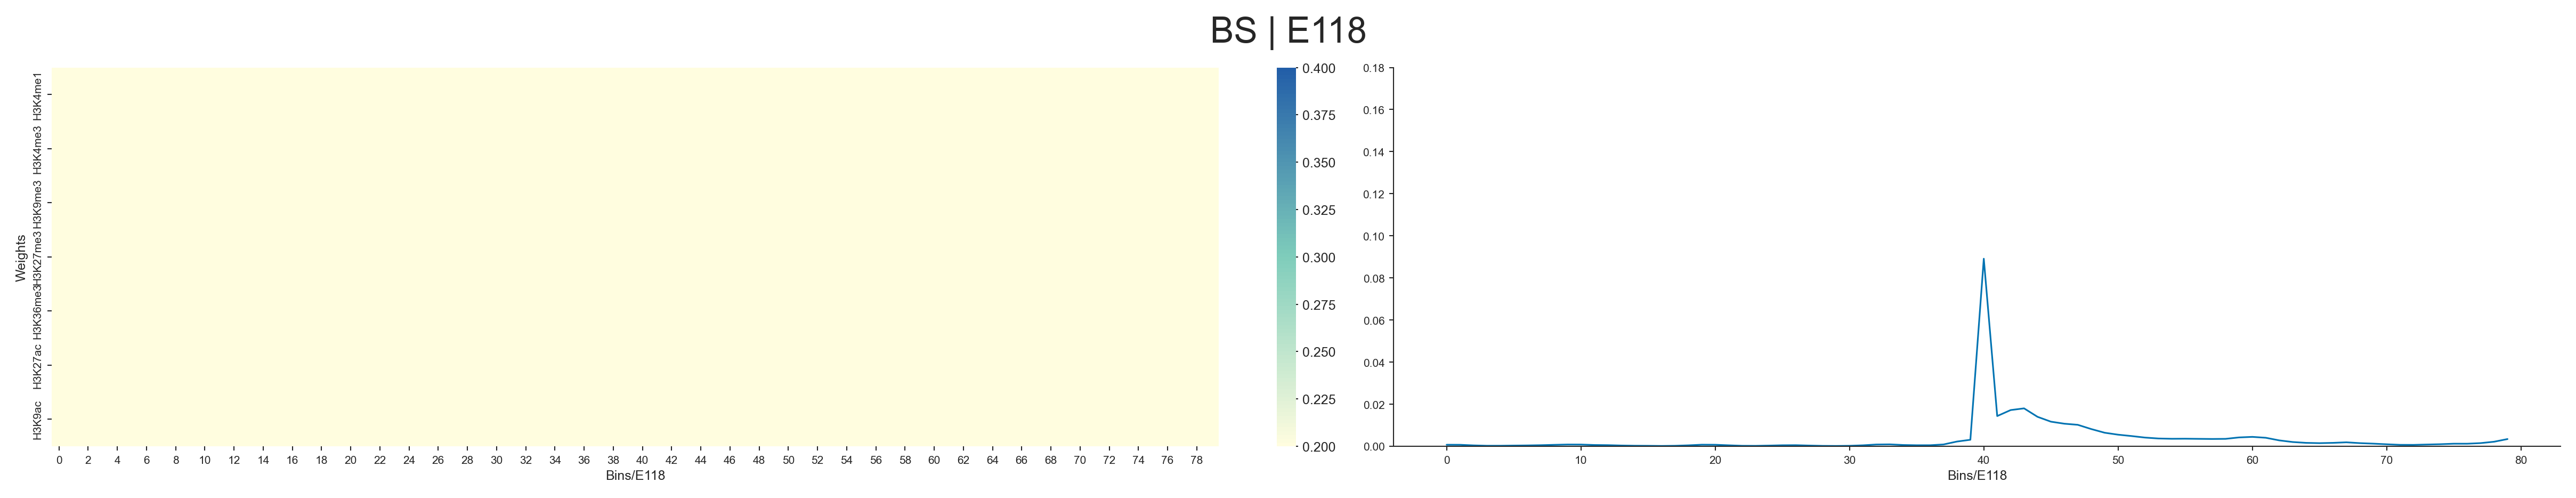

In [5]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)


fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

## BF Feature Importance

  0%|          | 0/3469 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3602/3602 [01:47<00:00, 33.66it/s]


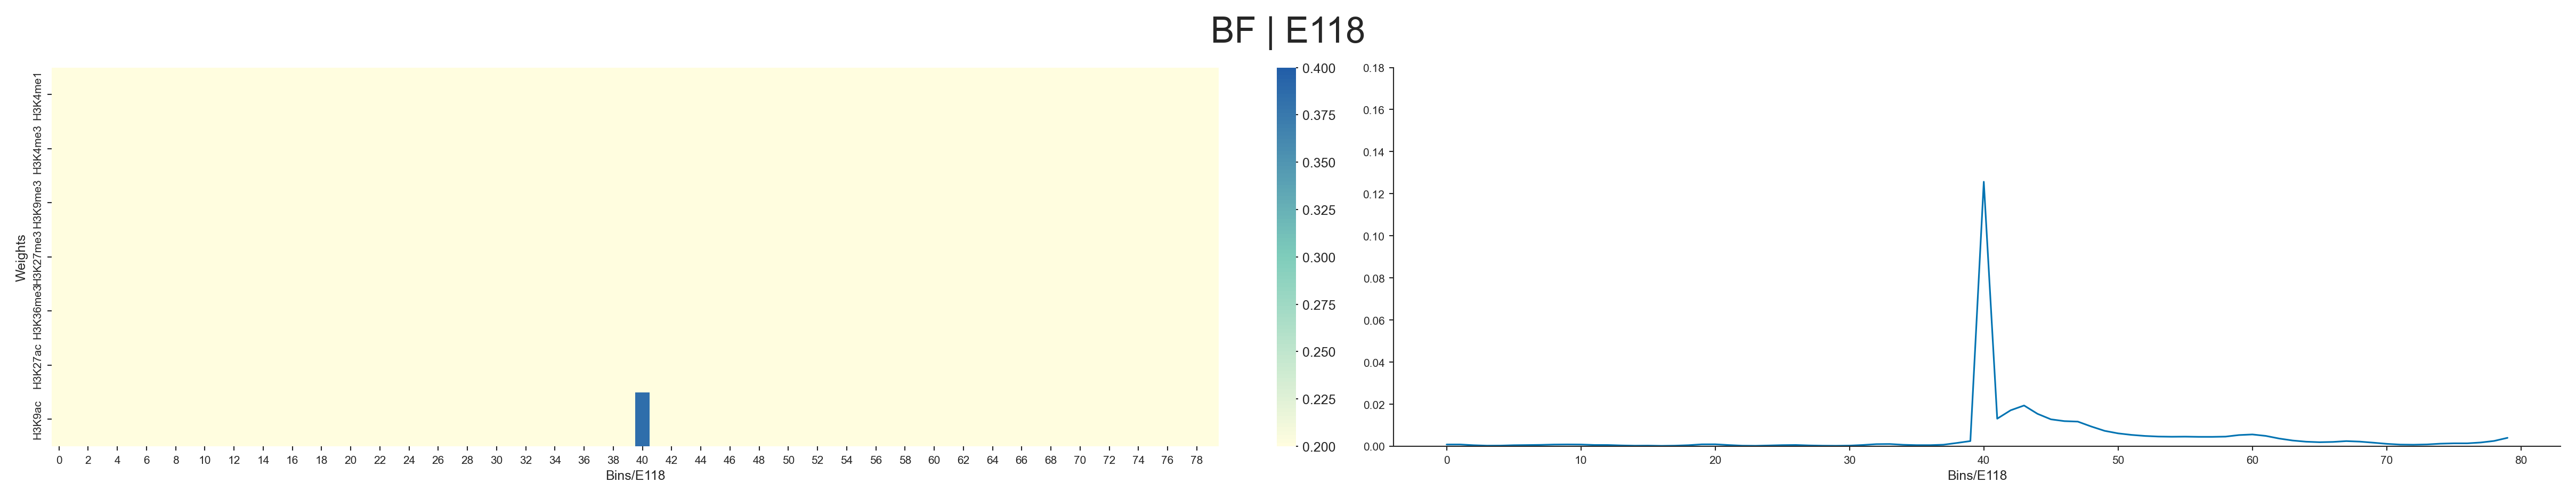

In [6]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bf_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)


fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

100%|██████████| 1812/1812 [00:50<00:00, 36.00it/s]


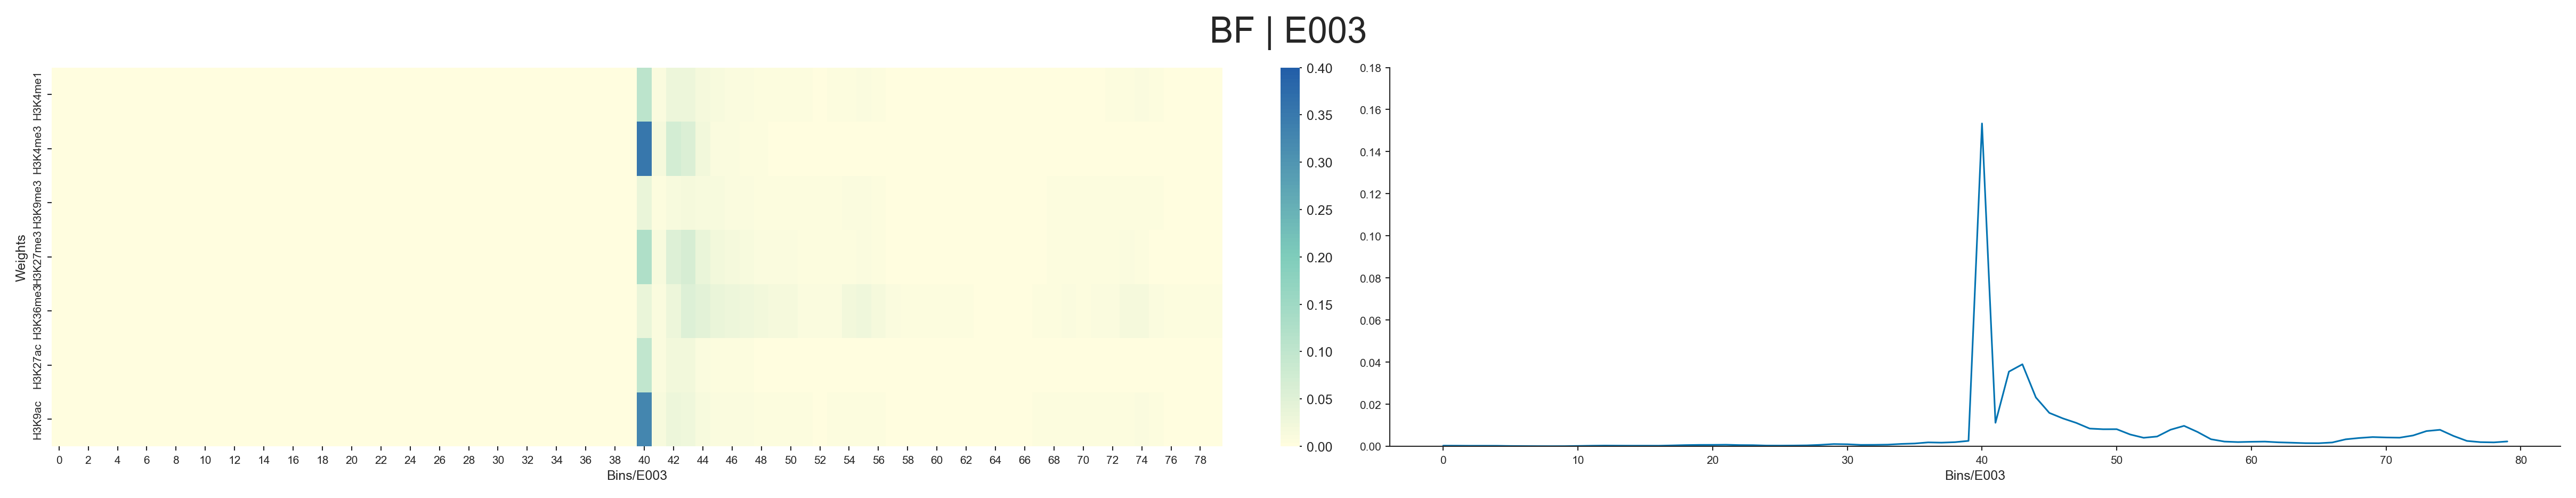

In [9]:
gene_ids = data[data['bs_label_label']==1]

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)
        baselines = torch.randn(1, 1, 80, 7)
        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_positive_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_positive_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

In [ ]:
gene_ids = data[data['bs_label_label']==0]

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_negative_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_negative_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

  0%|          | 0/1687 [00:00<?, ?it/s]

/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
 69%|██████▉   | 1166/1687 [00:36<00:17, 30.40it/s]

## HeatMap

In [1]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(5.5/2.54, 3.5/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap((attributions1), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[0], cbar=False)
ax[0].tick_params(axis='both', labelsize=5, width=0.5)

sns.heatmap((attributions2), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[1],cbar=False)
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10))
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[0].set_yticks(np.arange(len(yticks))+0.5)
ax[0].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_yticks(np.arange(len(yticks))+0.5)
ax[1].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')


ax[0].text(73,1.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(73,1.2,"BS",fontdict={"size":5,"color":"red"})

cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
# # 更改 colorbar 的字体大小
cbar.ax.tick_params(width=0.5, labelsize=5)
cbar.set_label('log10(Feature importance)',fontsize=5)

plt.savefig(f'extra/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

NameError: name 'eid' is not defined

## Lineplot

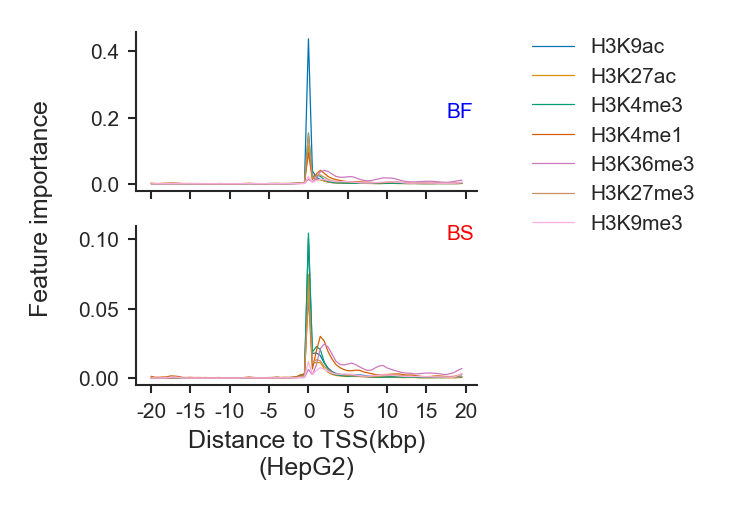

In [ ]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(4/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,ax=ax[0],linewidth=0.3)

ax[0].tick_params(axis='both', labelsize=5, width=0.5)

for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=ytick,ax=ax[1],linewidth=0.3)

ax[0].legend().remove()
ax[1].legend().remove()
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10),labels='')
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')

handles, labels = ax[0].get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=5,edgecolor='none')

ax[0].text(75,0.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(75,0.1,"BS",fontdict={"size":5,"color":"red"})


# plt.savefig(f'extra/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

## BS Feature Importance

  0%|          | 0/3749 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3736/3736 [01:46<00:00, 35.21it/s]


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (7).

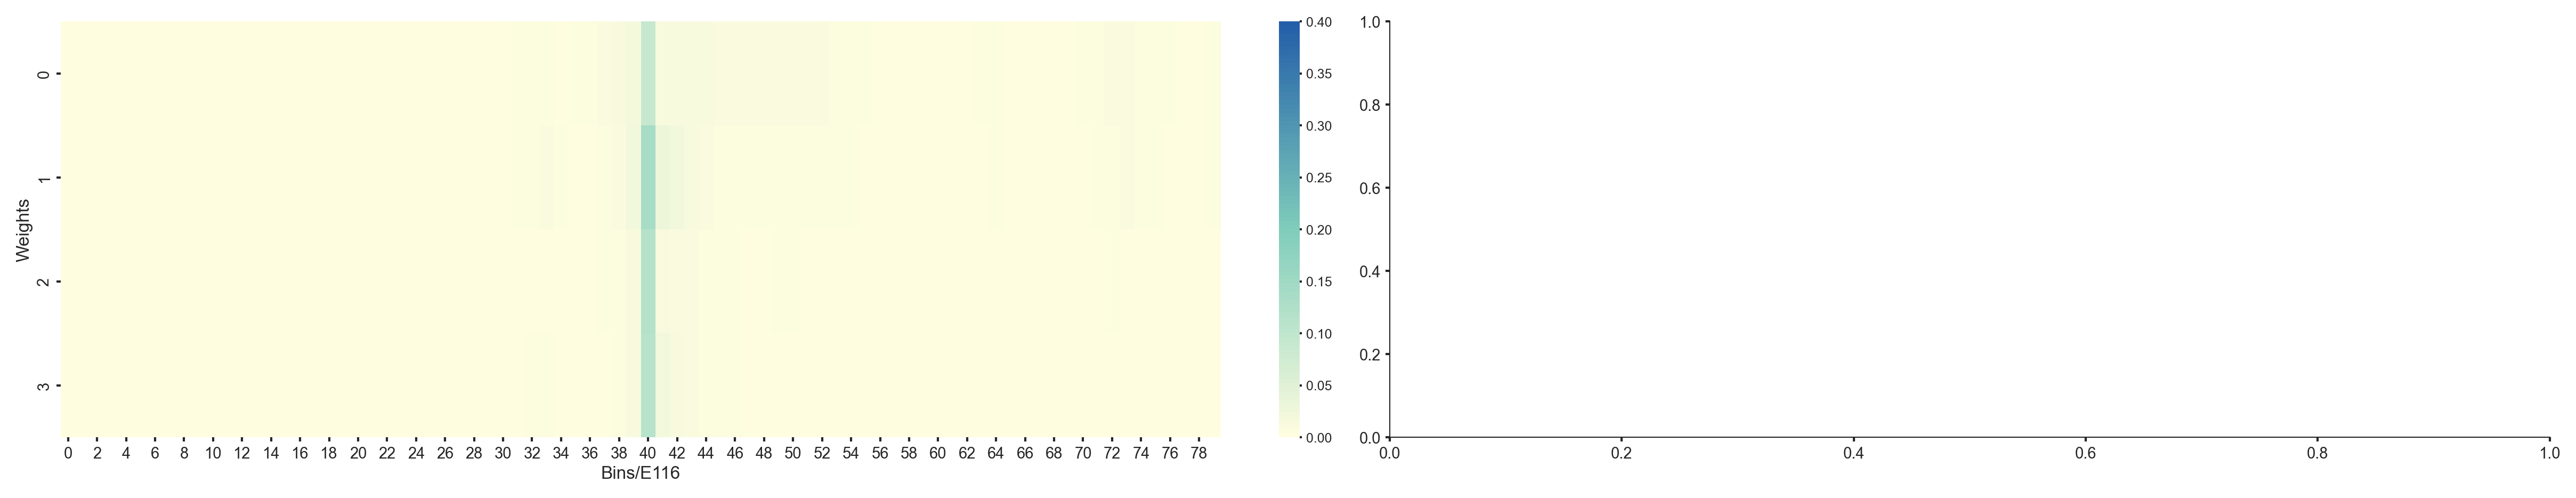

In [10]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_active_bs_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_active_bs_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)


fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights")


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

## BF Feature Importance

In [61]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_active_bf_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_active_bf_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights")


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

  0%|          | 0/3492 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
 30%|███       | 1050/3492 [00:34<01:20, 30.47it/s]


KeyboardInterrupt: 

## HeatMap

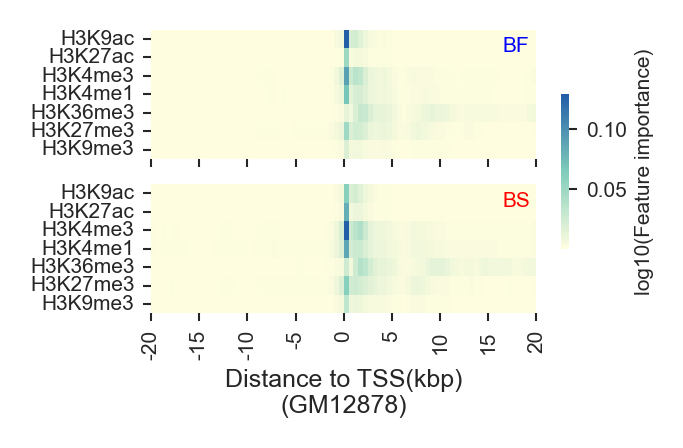

In [13]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(5.5/2.54, 3.5/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap((attributions1), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[0], cbar=False)
ax[0].tick_params(axis='both', labelsize=5, width=0.5)

sns.heatmap((attributions2), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[1],cbar=False)
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10))
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[0].set_yticks(np.arange(len(yticks))+0.5)
ax[0].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_yticks(np.arange(len(yticks))+0.5)
ax[1].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')


ax[0].text(73,1.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(73,1.2,"BS",fontdict={"size":5,"color":"red"})

cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
# # 更改 colorbar 的字体大小
cbar.ax.tick_params(width=0.5, labelsize=5)
cbar.set_label('log10(Feature importance)',fontsize=5)

# plt.savefig(f'extra/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

## Lineplot

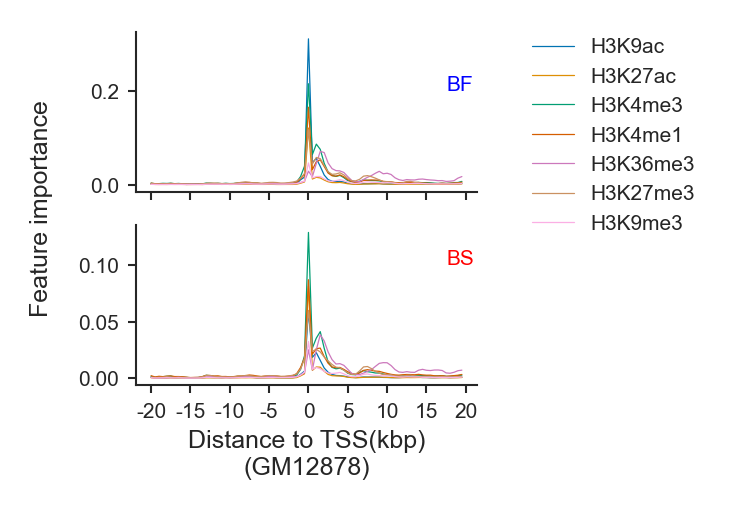

In [14]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(4/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,ax=ax[0],linewidth=0.3)

ax[0].tick_params(axis='both', labelsize=5, width=0.5)

for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=ytick,ax=ax[1],linewidth=0.3)

ax[0].legend().remove()
ax[1].legend().remove()
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10),labels='')
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')

handles, labels = ax[0].get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=5,edgecolor='none')

ax[0].text(75,0.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(75,0.1,"BS",fontdict={"size":5,"color":"red"})


# plt.savefig(f'extra/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

## BS Feature Importance

  0%|          | 0/3749 [00:00<?, ?it/s]

/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3736/3736 [01:42<00:00, 36.44it/s]


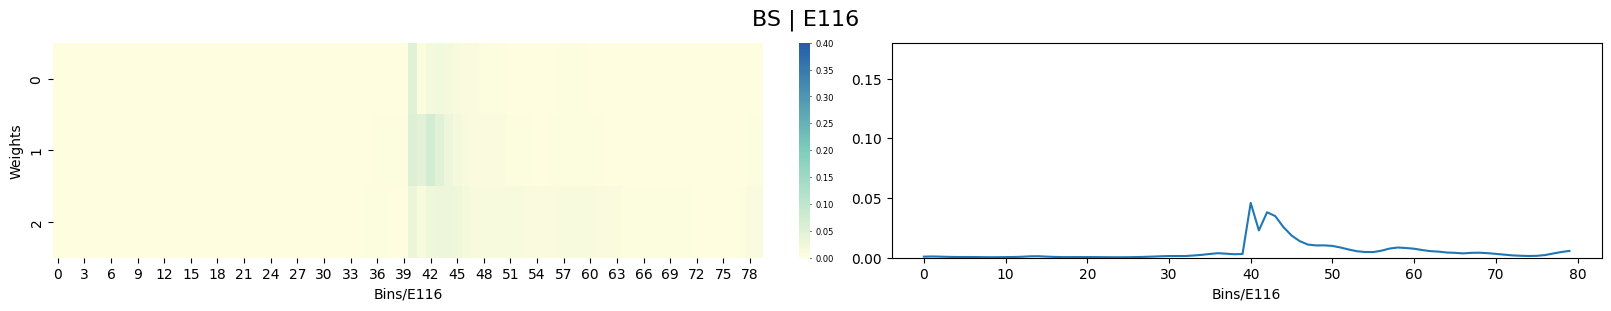

In [2]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_repressive_bs_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_repressive_bs_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)


fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights")


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

## BF Feature Importance

  0%|          | 0/3522 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3489/3489 [01:28<00:00, 39.48it/s]


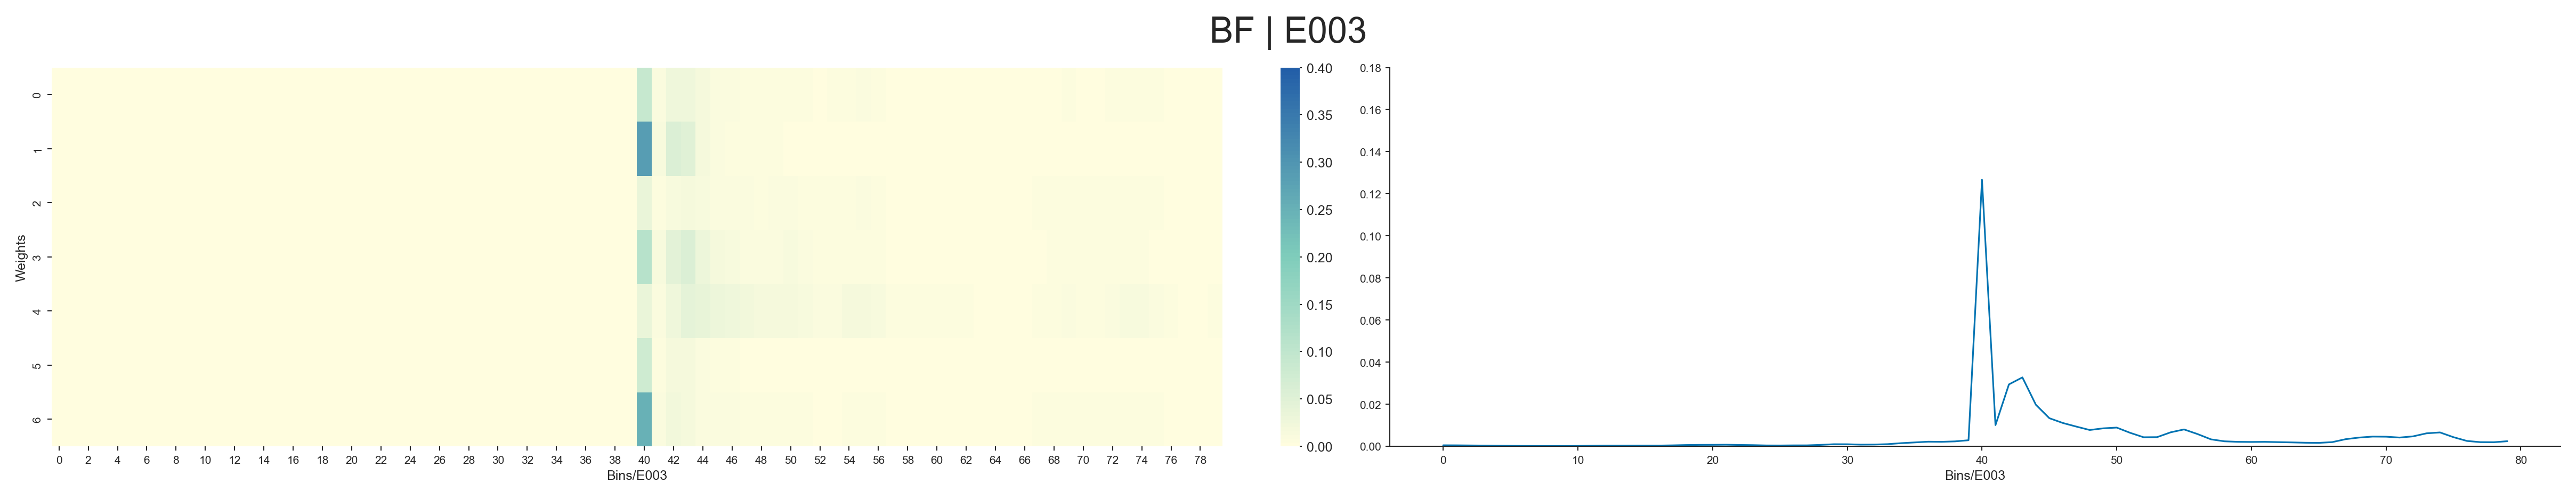

In [21]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_repressive_bf_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_repressive_bf_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights")


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

In [18]:
models

{}

## HeatMap

In [12]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_repressive_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_repressive_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(5.5/2.54, 3.5/2.54))

xticks = [i for i in range(0, 81, 10)]
sns.heatmap((attributions1), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[0], cbar=False)
ax[0].tick_params(axis='both', labelsize=5, width=0.5)

sns.heatmap((attributions2), cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),
            ax=ax[1],cbar=False)
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10))
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[0].set_yticks(np.arange(len(yticks))+0.5)
ax[0].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_yticks(np.arange(len(yticks))+0.5)
ax[1].set_yticklabels(yticks, rotation=360, fontsize=5)
ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')


ax[0].text(73,1.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(73,1.2,"BS",fontdict={"size":5,"color":"red"})

cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.outline.set_visible(False)
# # 更改 colorbar 的字体大小
cbar.ax.tick_params(width=0.5, labelsize=5)
cbar.set_label('log10(Feature importance)',fontsize=5)

plt.savefig(f'extra/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

IndexError: index 4 is out of bounds for axis 0 with size 3

## Lineplot

In [4]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_repressive_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_repressive_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax = plt.subplots(2, 1, constrained_layout=True, figsize=(4/2.54, 4/2.54))

xticks = [i for i in range(0, 81, 10)]
for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions1[_idx],label=ytick,ax=ax[0],linewidth=0.3)

ax[0].tick_params(axis='both', labelsize=5, width=0.5)

for _idx, ytick in enumerate(yticks):
   sns.lineplot(attributions2[_idx],label=ytick,ax=ax[1],linewidth=0.3)

ax[0].legend().remove()
ax[1].legend().remove()
ax[1].tick_params(axis='both', labelsize=5, width=0.5)

xticklabels = [int((i - 40) / 2) for i in range(0, 81, 10)]
ax[0].set_xticks(np.arange(0, 81, 10),labels='')
ax[1].set_xticks(np.arange(0, 81, 10), labels=xticklabels)

ax[1].set_xlabel(f"Distance to TSS(kbp)\n({EIDS_TO_CELLTYPES[eid]})", fontsize=6,ha='center')

handles, labels = ax[0].get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.supylabel(f"Feature importance", fontsize=6,y=0.6)
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=5,edgecolor='none')

ax[0].text(75,0.2,"BF",fontdict={"size":5,"color":"blue"})
ax[1].text(75,0.1,"BS",fontdict={"size":5,"color":"red"})


# plt.savefig(f'extra/figures/Figure3B_{EIDS_TO_CELLTYPES[eid]}.eps', format='eps', bbox_inches='tight')

plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 3

# Correlation between HMs

In [5]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=axis,vmin=vmin, vmax=vmax)
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        axis.set_xlabel(xlabel)
    
    if ylabel:
        axis.set_ylabel(ylabel)

    if xticklabels:
        axis.set_xticklabels(xticklabels)

    if yticklabels:
        axis.set_yticklabels(yticklabels)

    g.set_title(title)


In [ ]:
import os 
from scripts.utils import bin_and_padding
npy_dir = "extra/datasets/processed/v1"
for _eid in ['E003','E116','E118']:
    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{_eid}.csv"
    binsizes = [500]
    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # df = pd.merge(data,meta[['gene_id','strand']],how='inner',on='gene_id')
    gene_ids = list(meta[['gene_id','strand']].values)

    marks = np.array([bin_and_padding(np.load(os.path.join(npy_dir,_eid,f'regions/{gene_id}.npy')),strand=strand)[0][:7] for gene_id, strand in tqdm(gene_ids,desc='bin and padding')])
    MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
    ticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
    idxes = [MARKS.index(mark) for mark in ticks]

    correlation_matrices = [np.nan_to_num(np.corrcoef(mark[idxes])) for mark in tqdm(marks,desc='compute corr')]
    correlation = np.mean(correlation_matrices,axis=0)

    # correlation
    np.savetxt(f"extra/results/{_eid}_hm_correlation.csv", correlation, delimiter=",", fmt="%.3f") 



bin and padding: 100%|██████████| 14495/14495 [12:47<00:00, 18.89it/s]
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
bin and padding: 100%|██████████| 15487/15487 [04:01<00:00, 64.05it/s] 
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
bin and padding: 100%|██████████| 13882/13882 [01:16<00:00, 180.63it/s]
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/num

/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


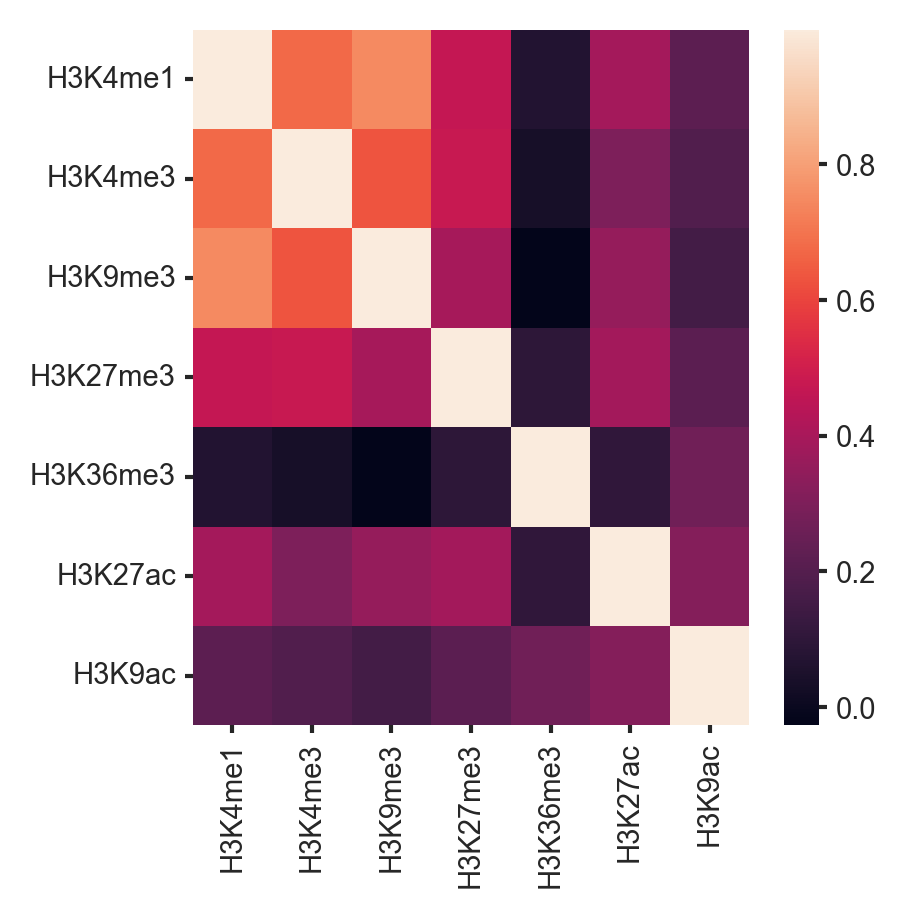

In [ ]:
correlation = np.loadtxt(f'extra/results/{eid}_hm_correlation.csv',delimiter=",")
# 选择第 0 个样本的行间相关性矩阵

MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
ax = sns.heatmap(correlation)
ax.set_xticklabels(MARKS,rotation=90)
ax.set_yticklabels(MARKS,rotation=360)
plt.show()


# Active & Repressive marks valid

In [5]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K27ac H3K9ac H3K4me1 H3K4me3 H3K36me3','H3K9me3 H3K27me3 H3K36me3']
target = 'bs'
with open(f'extra/results/active_repressive_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write(','.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                remove_mark = remove_mark.replace(' ','_')
                checkpoints = f'checkpoints/{eid}.{remove_mark}.{fold}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"{remove_mark}",str(fold), eid]
                w.write(','.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.bs_bf_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt[f'{target}_label_val_auc']
            line = [str(auc),'all_marks',str(fold),eid]
            w.write(','.join(line) + '\n')       

data = pd.read_csv(f'extra/results/active_repressive_{target}_para.csv')

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_29303/4086417333.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


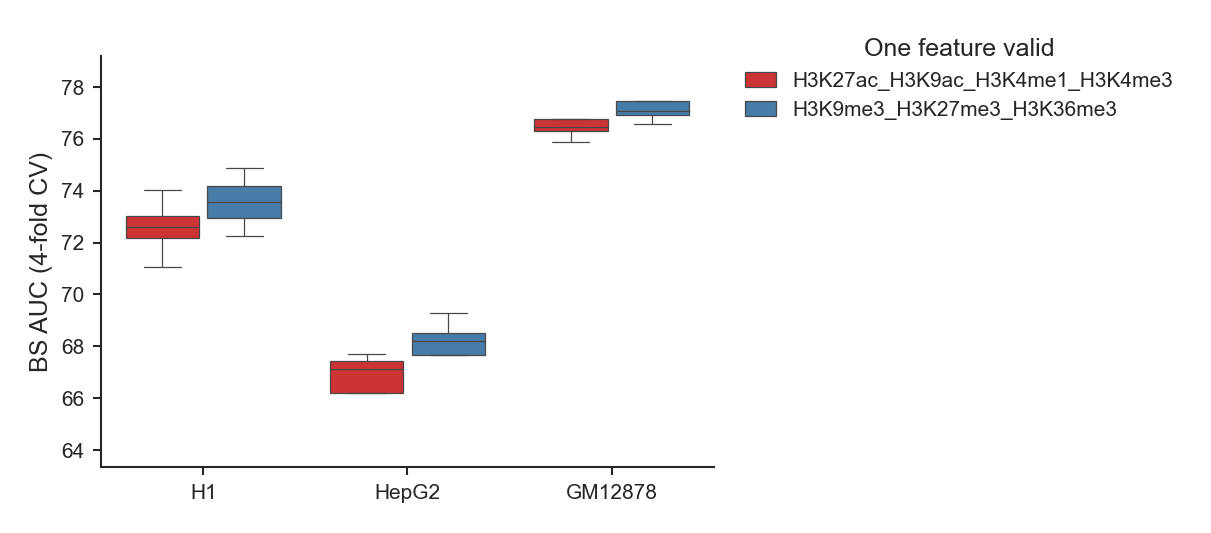

In [6]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))


# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3_H3K36me3','H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3'],name='marks')

order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BS AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

In [7]:
import torch 
from src.utils.constants import DEVICE

eids = ['E003','E118','E116']
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
marks = ['H3K27ac H3K9ac H3K4me1 H3K4me3','H3K27ac H3K9ac H3K4me1 H3K4me3 H3K36me3','H3K9me3 H3K27me3 H3K36me3']
target = 'bf'
with open(f'extra/results/active_repressive_{target}_para.csv','w') as w:
    line = ['auc','remove_mark','fold','eid']
    w.write(','.join(line) + '\n')
    for eid in eids:
        for fold in [0,1,2,3]:
            for remove_mark in marks:
                remove_mark = remove_mark.replace(' ','_')
                checkpoints = f'checkpoints/{eid}.{remove_mark}.{fold}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                auc = ckpt[f'{target}_label_val_auc']
                line = [str(auc),f"{remove_mark}",str(fold), eid]
                w.write(','.join(line) + '\n')

            checkpoints = f'checkpoints/{eid}.{fold}.bs_bf_para.model.pt'
            ckpt = torch.load(checkpoints,map_location=DEVICE)
            auc = ckpt[f'{target}_label_val_auc']
            line = [str(auc),'all_marks',str(fold),eid]
            w.write(','.join(line) + '\n')       

data = pd.read_csv(f'extra/results/active_repressive_{target}_para.csv')

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_29303/3892034678.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


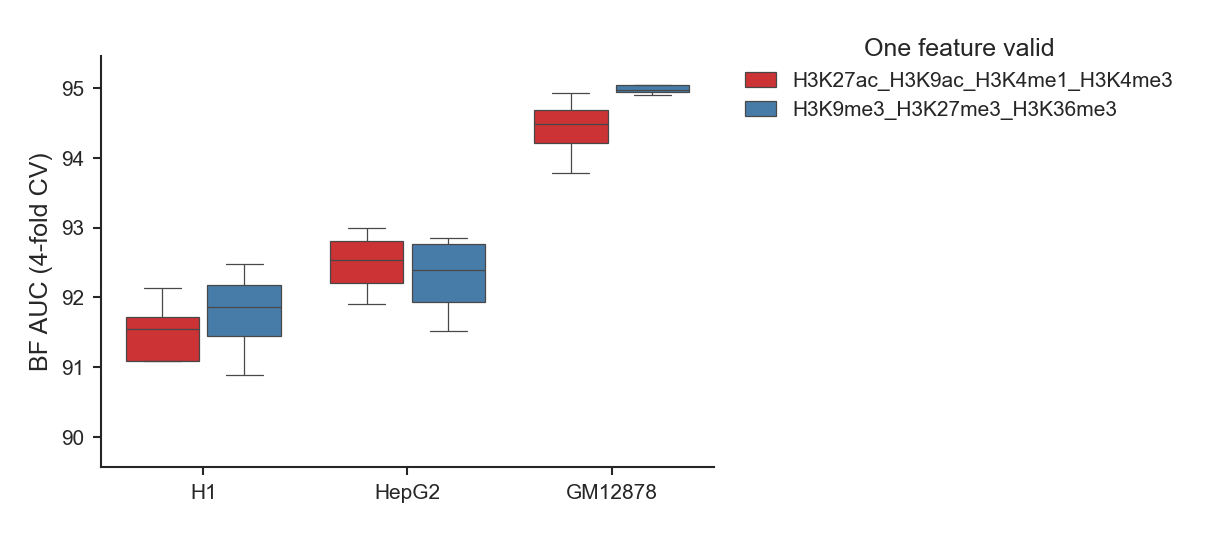

In [8]:
# 设置为 colorblind 调色板
# sns.set_palette("colorblind")
# sns.set_context("paper") 
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(6/2.54, 4/2.54))

# hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3_H3K36me3','H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3','all_marks'],name='marks')
hue_order = pd.Index(['H3K27ac_H3K9ac_H3K4me1_H3K4me3','H3K9me3_H3K27me3_H3K36me3'],name='marks')
order = pd.Index(["E003","E118","E116"],name='marks')
ax = sns.boxplot(data=data,y='auc',x='eid',hue='remove_mark',
                 gap=0.1,width=0.8,fliersize=0,order=order,hue_order=hue_order,linewidth=0.3,
                 palette="Set1")
ax.tick_params(axis='both', labelsize=5,width=0.5)
plt.ylabel(f'BF AUC (4-fold CV)',fontsize=6)
# ax.set_ylim(top=4)
ax.set_xlabel('')
ax.legend().remove()
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  
# plt.savefig('extra/figures/Figure3E_MEAN.eps', format='eps', bbox_inches='tight')
plt.show()

# Combination

In [31]:
# eid = 'E003'

tags = ["H3K4me1_H3K4me3", "H3K4me1_H3K9me3", "H3K4me1_H3K27me3", "H3K4me1_H3K36me3", "H3K4me1_H3K27ac", "H3K4me1_H3K9ac", "H3K4me3_H3K9me3", "H3K4me3_H3K27me3", "H3K4me3_H3K36me3", "H3K4me3_H3K27ac", "H3K4me3_H3K9ac", "H3K9me3_H3K27me3", "H3K9me3_H3K36me3", "H3K9me3_H3K27ac", "H3K9me3_H3K9ac", "H3K27me3_H3K36me3", "H3K27me3_H3K27ac", "H3K27me3_H3K9ac", "H3K36me3_H3K27ac", "H3K36me3_H3K9ac", "H3K27ac_H3K9ac"]
# tag = 'H3K4me3_H3K9ac'
# fold = 0

targets=['bs_label','bf_label']
with open('extra/results/bs_bf_para_keep_marks_indicators.csv','w') as w:
    line = ['eid','fold','auc','target','keep_marks']
    w.write(','.join(line) + '\n')
    for eid in ["E003","E116","E118"]:
        for tag in tags:    
            for fold in [0,1,2,3]:
                checkpoints = f'checkpoints/{eid}.keep_{tag}.{fold}.bs_bf_para.model.pt'
                ckpt = torch.load(checkpoints,map_location=DEVICE)
                for target in targets:
                    auc = ckpt[f"{target}_val_auc"]
                    line = [eid,str(fold),str(auc),target,tag]
                    w.write(','.join(line) + '\n')


In [20]:
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data1 = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
marks = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
mark_region = {
    "H3K4me1": 'Enhencer',
    "H3K4me3": "Promoter",
    "H3K9me3": "H3K9me3",
    "H3K27me3": "PromoterGenebody",
    "H3K36me3": "Genebody",
    "H3K27ac": "Enhencer",
    "H3K9ac": "Promoter"

}
def _func(row):
    row_split = [mark_region[mark] for mark in row['keep_marks'].split('_')]
    row_split.sort()
    return '_'.join(row_split)


data['combine_region'] = data.apply(lambda row:_func(row) ,axis=1)
data

,eid,fold,auc,target,keep_marks,combine_region
0,E003,0,73.474074,bs_label,H3K4me1_H3K4me3,Enhencer_Promoter
1,E003,0,90.203523,bf_label,H3K4me1_H3K4me3,Enhencer_Promoter
2,E003,1,73.064536,bs_label,H3K4me1_H3K4me3,Enhencer_Promoter
3,E003,1,91.729394,bf_label,H3K4me1_H3K4me3,Enhencer_Promoter
4,E003,2,75.230875,bs_label,H3K4me1_H3K4me3,Enhencer_Promoter
...,...,...,...,...,...,...
499,E118,1,91.901739,bf_label,H3K27ac_H3K9ac,Enhencer_Promoter
500,E118,2,67.724821,bs_label,H3K27ac_H3K9ac,Enhencer_Promoter
501,E118,2,91.942593,bf_label,H3K27ac_H3K9ac,Enhencer_Promoter
502,E118,3,67.122412,bs_label,H3K27ac_H3K9ac,Enhencer_Promoter


In [78]:
keep_marks1 = ['H3K27ac_H3K9ac','H3K4me3_H3K27ac','H3K9me3_H3K27ac','H3K36me3_H3K27ac','H3K4me1_H3K27ac','H3K27me3_H3K27ac']
# order = keep_marks1 + [mark for mark in keep_marks if mark not in keep_marks1]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


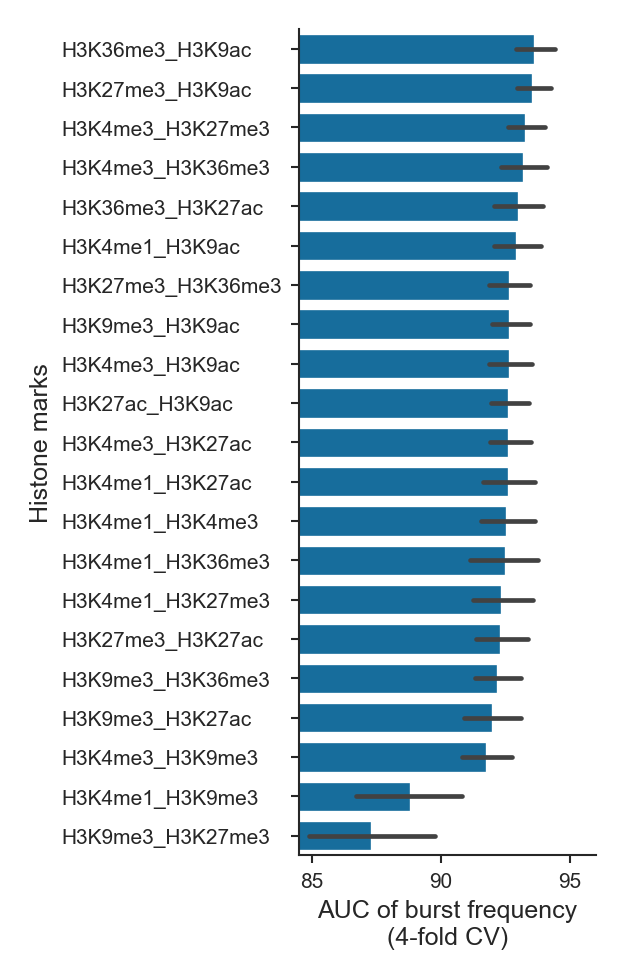

In [4]:
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')

# repressive_marks = ['H3K9me3','H3K4me1','H3K27me3','H3K36me3','H3K4me3']
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 8/2.54))
keep_marks = 'H3K4me3'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') ]
sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
ax = sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks)
ax.set_xlim(84.5, 96)
xticklabels = list(range(85,96,5))
ax.set_xticks(xticklabels)
ax.set_xticklabels(xticklabels)
ax.set_yticks(sorted_keep_marks)
ax.set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax.tick_params(axis='y', pad=55)  # 控制文字与坐标轴的间距，单位是点

ax.set_ylabel('Histone marks',fontsize=6)
ax.set_xlabel('AUC of burst frequency\n(4-fold CV)',fontsize=6)
ax.legend().remove()
plt.savefig('extra/figures/v5/Figure4E.eps', format='eps', bbox_inches='tight')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


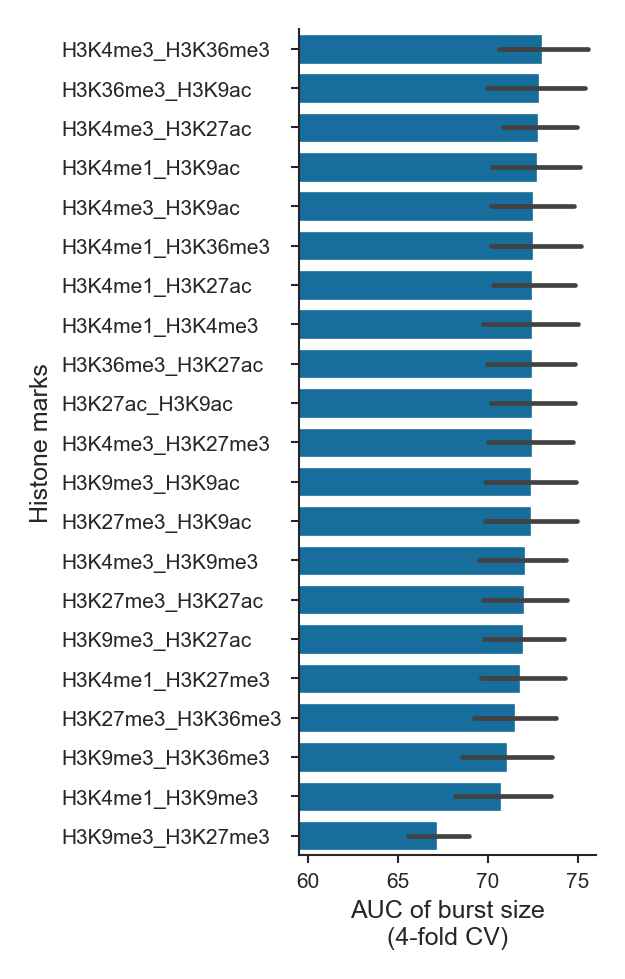

In [7]:
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')

# repressive_marks = ['H3K9me3','H3K4me1','H3K27me3','H3K36me3','H3K4me3']
fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 8/2.54))
# keep_marks = 'H3K4me3'

data = data[(data['target'] == 'bs_label')]
sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
ax = sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks)
ax.set_xlim(59.5, 76)
xticklabels = list(range(60,76,5))
ax.set_xticks(xticklabels)
ax.set_xticklabels(xticklabels)
ax.set_yticks(sorted_keep_marks)
ax.set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax.tick_params(axis='y', pad=55)  # 控制文字与坐标轴的间距，单位是点

ax.set_ylabel('Histone marks',fontsize=6)
ax.set_xlabel('AUC of burst size\n(4-fold CV)',fontsize=6)
ax.legend().remove()
# plt.savefig('extra/figures/v5/Figure4E.eps', format='eps', bbox_inches='tight')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


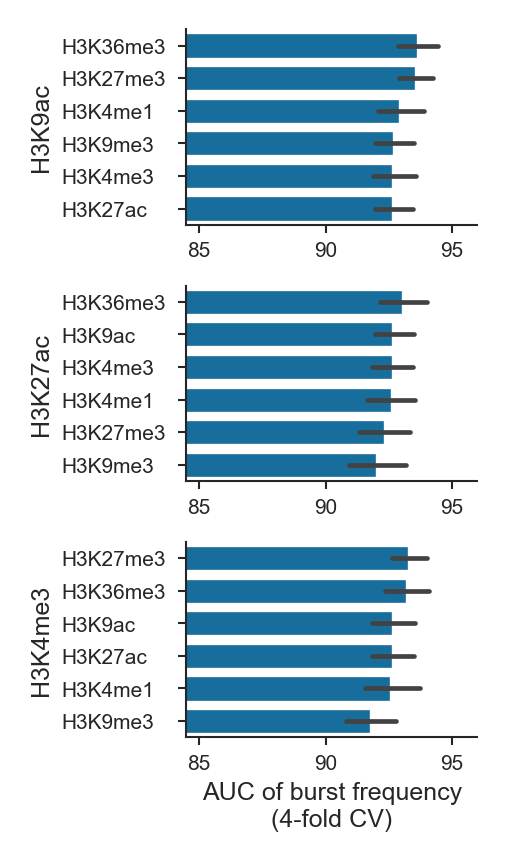

In [7]:
data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')

# repressive_marks = ['H3K9me3','H3K4me1','H3K27me3','H3K36me3','H3K4me3']
fig, ax = plt.subplots(3,1, constrained_layout=True, figsize=(4/2.54, 7/2.54))
keep_mark = 'H3K9ac'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))]
def _func(row, target_mark):
    marks = row['keep_marks'].split('_')
    marks.remove(target_mark)
    return marks[0]

data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark),axis=1)

sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[0])
ax[0].set_xlim(84.5, 96)
xticklabels = list(range(85,96,5))
ax[0].set_xticks(xticklabels)
ax[0].set_xticklabels(xticklabels)
ax[0].set_yticks(sorted_keep_marks)
ax[0].set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax[0].tick_params(axis='y', pad=28)  # 控制文字与坐标轴的间距，单位是点
ax[0].set_ylabel(keep_mark,fontsize=6)
# ax[0].set_xlabel('AUC of burst frequency\n(4-fold CV)',fontsize=6)
ax[0].set_xlabel('')

ax[0].legend().remove()

data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
keep_mark = 'H3K27ac'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))]
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark),axis=1)
sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[1])
ax[1].set_xlim(84.5, 96)
xticklabels = list(range(85,96,5))
ax[1].set_xticks(xticklabels)
ax[1].set_xticklabels(xticklabels)
ax[1].set_yticks(sorted_keep_marks)
ax[1].set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax[1].tick_params(axis='y', pad=28)  # 控制文字与坐标轴的间距，单位是点

ax[1].set_ylabel(keep_mark,fontsize=6)
# ax[1].set_xlabel('AUC of burst frequency\n(4-fold CV)',fontsize=6)
ax[1].set_xlabel('')
ax[1].legend().remove()


data = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
keep_mark = 'H3K4me3'

# data = data[(data['target'] == 'bf_label') &(data['keep_marks'].str.contains(keep_marks))]
data = data[(data['target'] == 'bf_label') & (data['keep_marks'].str.contains(keep_mark))]
data['keep_marks'] = data.apply(lambda row: _func(row, keep_mark),axis=1)
sorted_keep_marks = data.groupby('keep_marks')['auc'].mean().sort_values(ascending=False).index
# 绘制 barplot，并按照排序后的 keep_marks 显示
sns.barplot(data=data, x='auc', y='keep_marks', order=sorted_keep_marks,ax=ax[2])
ax[2].set_xlim(84.5, 96)
xticklabels = list(range(85,96,5))
ax[2].set_xticks(xticklabels)
ax[2].set_xticklabels(xticklabels)
ax[2].set_yticks(sorted_keep_marks)
ax[2].set_yticklabels(sorted_keep_marks,fontsize=5,ha='left')
ax[2].tick_params(axis='y', pad=28)  # 控制文字与坐标轴的间距，单位是点

ax[2].set_ylabel(keep_mark,fontsize=6)
ax[2].set_xlabel('AUC of burst frequency\n(4-fold CV)',fontsize=6)
ax[2].legend().remove()
plt.savefig('extra/figures/v5/Figure4E.eps', format='eps', bbox_inches='tight')

plt.show()

In [4]:
target = 'bf_label'
keep_mark = 'H3K9ac'
data1 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/bs_bf_para_keep_marks_indicators.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

# data = data[(data['eid']==eid) & (data['target'] == target) & (data['mark2']==keep_mark)]
data = data[(data['target'] == target)]

data2 = pd.read_csv(f'extra/results/one_feature_indicators_{target[:2]}_para.csv')
data2.columns = ['eid','mark2','fold','auc_single_mark2']

data = pd.merge(data,data2,on = ['eid','mark2','fold'])
data['improvement'] = data['auc'] - data['auc_single_mark2']

mark1 = 'H3K36me3'
# mark2 = 'H3K27ac'
data = data[data['mark2'] != mark1]
data['is_mark1_combine'] = data.apply(lambda row: mark1 if row['mark1']==mark1 else "Average", axis=1)

data


,eid,fold,auc,target,keep_marks,mark1,mark2,auc_single_mark2,improvement,is_mark1_combine
0,E003,0,90.203523,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,89.106162,1.097361,Average
1,E003,1,91.729394,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,91.327470,0.401925,Average
2,E003,2,91.751416,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,91.281197,0.470219,Average
3,E003,3,92.094984,bf_label,H3K4me1_H3K4me3,H3K4me1,H3K4me3,91.038546,1.056438,Average
4,E003,0,83.329570,bf_label,H3K4me1_H3K9me3,H3K4me1,H3K9me3,60.045805,23.283765,Average
...,...,...,...,...,...,...,...,...,...,...
491,E118,3,93.914396,bf_label,H3K27me3_H3K9ac,H3K9ac,H3K27me3,88.700189,5.214207,Average
500,E118,0,91.586776,bf_label,H3K27ac_H3K9ac,H3K9ac,H3K27ac,90.792837,0.793939,Average
501,E118,1,91.901739,bf_label,H3K27ac_H3K9ac,H3K9ac,H3K27ac,91.303055,0.598685,Average
502,E118,2,91.942593,bf_label,H3K27ac_H3K9ac,H3K9ac,H3K27ac,91.587249,0.355344,Average


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_53419/1903376555.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


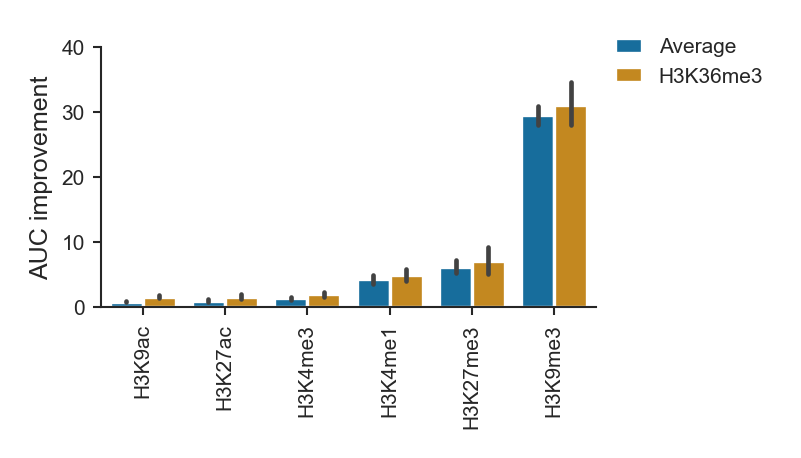

In [18]:

data1 = data[data['eid']=='E116']

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 3.5/2.54))
order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K27me3','H3K9me3']
sns.barplot(data=data,x='mark2',y='improvement',hue='is_mark1_combine',order=order)
# ax.set_ylabel(mark2)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.legend().remove()


handles, labels = ax.get_legend_handles_labels()
labels = [ "Average",mark1]
ax.set_xlabel('')
ax.set_ylabel('AUC improvement')
ax.set_yticks([i for i in range(0,41,10)])
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper left',title=None ,title_fontsize=6, bbox_to_anchor=(0.98, 1.02), fontsize=5,ncol=1,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
plt.savefig('extra/figures/v5/Figure4F.eps', format='eps', bbox_inches='tight')

plt.show()


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_34802/3875968651.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


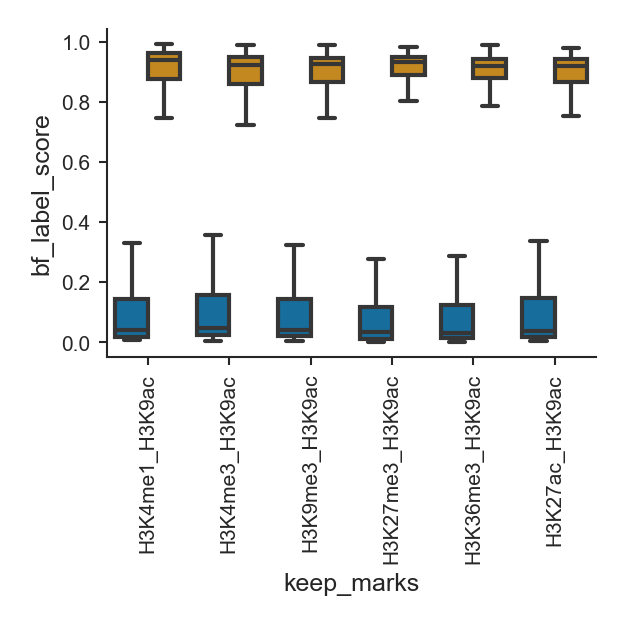

In [4]:
data = pd.read_csv(f'extra/results/keep_marks_predictions_bs_bf.csv')
eid = 'E116'
keep_mark = 'H3K9ac'
data = data[(data['eid']==eid) & (data['keep_marks'].str.contains(keep_mark)) ]
data

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 5/2.54))
sns.boxplot(data=data, x='keep_marks',y='bf_label_score',hue='bf_label_label',fliersize=0)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.legend().remove()
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_3053/3896894715.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


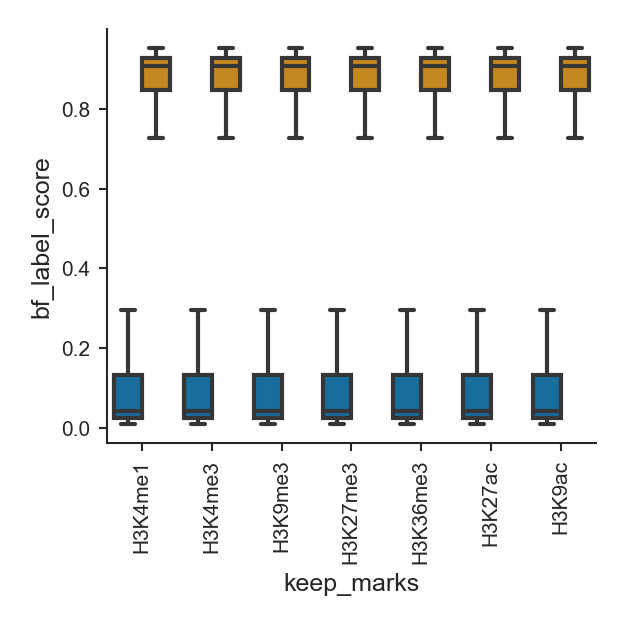

In [51]:
data = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')
eid = 'E116'
keep_mark = 'H3K27ac'
data = data[(data['eid']==eid)]
data

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 5/2.54))
sns.boxplot(data=data, x='keep_marks',y='bf_label_score',hue='bf_label_label',fliersize=0)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.legend().remove()
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_63322/1001678935.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


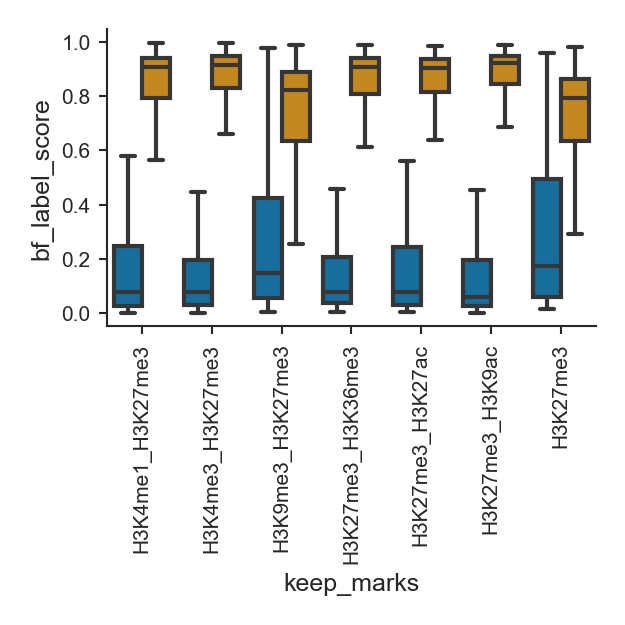

In [72]:
eid = 'E116'
keep_mark = 'H3K27me3'

data1 = pd.read_csv(f'extra/results/keep_marks_predictions_bs_bf.csv')
# data1 = data1[(data1['eid']==eid) & (data1['keep_marks'].str.contains(keep_mark)) ]
data1 = data1[(data1['keep_marks'].str.contains(keep_mark)) ]
data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')
# data2 = data2[(data2['eid']==eid) & (data2['keep_marks'].str.contains(keep_mark)) ]
data2 = data2[(data2['keep_marks'].str.contains(keep_mark)) ]

data = pd.concat([data1,data2],axis=0)
data

fig, ax = plt.subplots(1,1, constrained_layout=True, figsize=(5/2.54, 5/2.54))
sns.boxplot(data=data, x='keep_marks',y='bf_label_score',hue='bf_label_label',fliersize=0)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
ax.legend().remove()
plt.show()



# H3K36me3

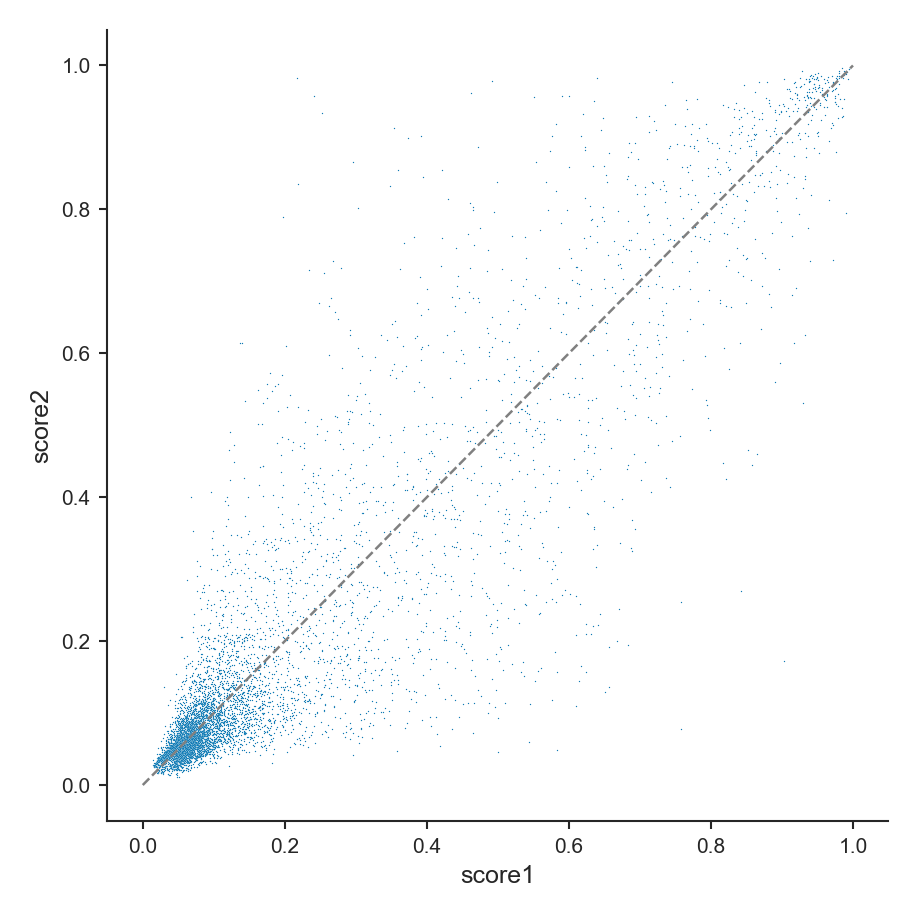

In [29]:
eid = 'E003'
remove_mark = 'H3K27me3'
data1 = pd.read_csv('extra/results/predictions_bs_bf.csv')
data1 = data1[(data1['eid']==eid) & (data1['bf_label_label']==0)]
data1 = data1[['gene_id','bf_label_score']]
data1.columns = ['gene_id','score1']
data2 = pd.read_csv(f'extra/results/remove_mark_predictions_bs_bf.csv')
data2 = data2[(data2['eid']==eid) & (data2['bf_label_label']==0) & (data2['remove_mark']==remove_mark)]
data2 = data2[['gene_id','bf_label_score']]
data2.columns = ['gene_id','score2']

data = pd.merge(data1,data2,on='gene_id')

sns.scatterplot(data=data,x='score1',y='score2',s=0.1)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6)

plt.show()
# data

In [79]:
eid = 'E118'
mark1 = 'H3K27me3'
mark2 = 'H3K27ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])
data


,gene_id,bf_label_label,score1,pred1,eid,fold,score2,pred2
0,ENSG00000154760,0,0.020288,0,E118,0,0.032085,0
1,ENSG00000125354,1,0.889694,1,E118,0,0.643602,1
2,ENSG00000198336,0,0.025691,0,E118,0,0.046445,0
3,ENSG00000203879,1,0.656954,1,E118,0,0.205209,0
4,ENSG00000188766,0,0.020124,0,E118,0,0.035868,0
...,...,...,...,...,...,...,...,...
13849,ENSG00000114982,1,0.920229,1,E118,3,0.911122,1
13850,ENSG00000186487,0,0.018750,0,E118,3,0.040051,0
13851,ENSG00000002549,1,0.951369,1,E118,3,0.907814,1
13852,ENSG00000084733,1,0.929806,1,E118,3,0.945253,1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


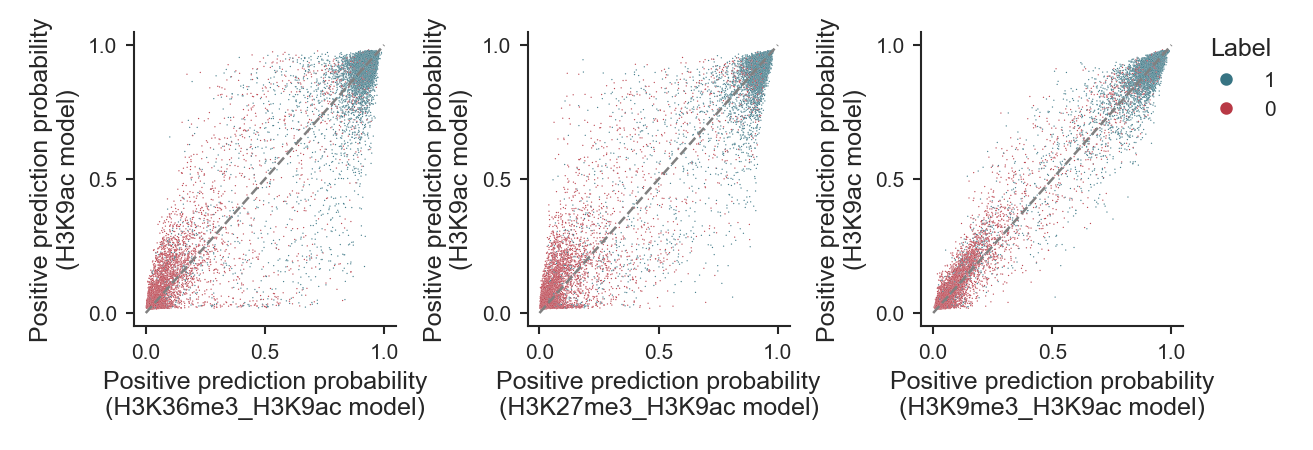

In [23]:
palette = ["#B83945","#377483"]
fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(10/2.54, 3.5/2.54))


eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[0],palette=palette)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[0])
ax[0].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[0].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].legend().remove()

eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[1],palette=palette)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[1])
ax[1].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[1].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[1].set_xticks([i/10 for i in range(0,11,5)])
ax[1].set_yticks([i/10 for i in range(0,11,5)])
ax[1].legend().remove()


eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[2],palette=palette)
sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[2])
ax[2].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[2].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[2].set_xticks([i/10 for i in range(0,11,5)])
ax[2].set_yticks([i/10 for i in range(0,11,5)])
ax[2].legend().remove()


import matplotlib.lines as mlines
legend_patches = [
    mlines.Line2D([],[],marker='o', linestyle='None',color=palette[1], markersize=2, label=1),
    mlines.Line2D([],[],marker='o', linestyle='None',color=palette[0], markersize=2, label=0),
]

fig.legend(handles=legend_patches, title="Label", loc="upper left", bbox_to_anchor=(0.99, 1), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')
plt.savefig('extra/figures/v5/Figure4G.eps', format='eps', bbox_inches='tight')

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


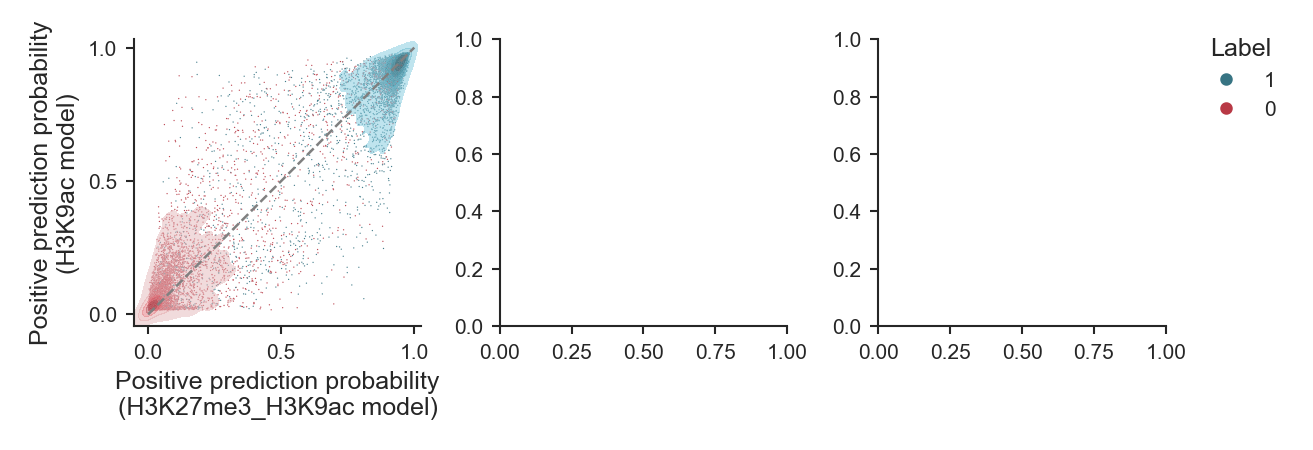

In [11]:
palette = ["#B83945","#377483"]
fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(10/2.54, 3.5/2.54))

eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]
data.columns = ['gene_id','bf_label_label','score1','pred1','eid','fold']

data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold']]

data2.columns = ['gene_id','bf_label_label','score2','pred2','eid','fold']
data = pd.merge(data,data2, on=['gene_id','bf_label_label','eid','fold'])

sns.scatterplot(data=data,x='score1',y='score2',hue='bf_label_label',s=0.1, ax=ax[0],palette=palette)
# sns.kdeplot(data=data,x='score1',y='score2',hue='bf_label_label',ax=ax[0])
sns.kdeplot(
    data=data[(data['bf_label_label'] == 0) & (data['pred1'] == 0) & (data['pred2'] == 0) ],
    x='score1', 
    y='score2', 
    ax=ax[0], color=palette[0], fill=True, levels=5, alpha=0.5
)

sns.kdeplot(
    data=data[(data['bf_label_label'] == 1) & (data['pred1'] == 1) & (data['pred2'] == 1) ],
    x='score1', 
    y='score2', 
    ax=ax[0], color=palette[1], fill=True, levels=5, alpha=0.5
)

sns.lineplot(x=[0, 1], y=[0, 1], color='gray', linestyle='--', linewidth=0.6, ax=ax[0])
ax[0].set_ylabel(f'Positive prediction probability\n({mark2} model)',fontsize=6)
ax[0].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].legend().remove()


import matplotlib.lines as mlines
legend_patches = [
    mlines.Line2D([],[],marker='o', linestyle='None',color=palette[1], markersize=2, label=1),
    mlines.Line2D([],[],marker='o', linestyle='None',color=palette[0], markersize=2, label=0),
]

fig.legend(handles=legend_patches, title="Label", loc="upper left", bbox_to_anchor=(0.99, 1), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')
# plt.savefig('extra/figures/v5/Figure4G.eps', format='eps', bbox_inches='tight')

plt.show()

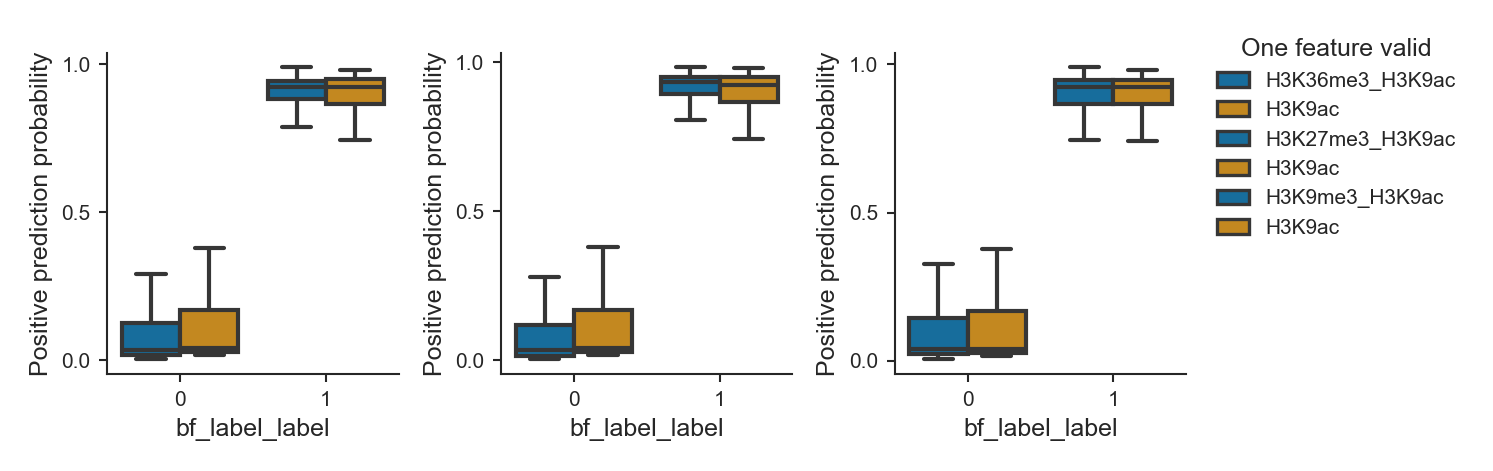

In [5]:
import scipy.stats as stats

palette = ["#B83945","#377483"]
fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))


eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)

data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])

data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
print(p_value_pos,p_value_neg)

sns.boxplot(data=data,x='bf_label_label',y='bf_label_score',hue='keep_marks',fliersize=0,ax=ax[0],linewidth=0.5)


ax[0].set_ylabel(f'Positive prediction probability',fontsize=6)
# ax[0].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
# ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].legend().remove()



eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)




data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])

data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
print(p_value_pos,p_value_neg)

sns.boxplot(data=data,x='bf_label_label',y='bf_label_score',hue='keep_marks',fliersize=0,ax=ax[1],linewidth=0.5)


ax[1].set_ylabel(f'Positive prediction probability',fontsize=6)
# ax[1].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
# ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[1].set_yticks([i/10 for i in range(0,11,5)])
ax[1].legend().remove()


eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bf_label_label','bf_label_score','bf_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)


data_1 = data[(data['bf_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_pos = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])

data_1 = data[(data['bf_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bf_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_neg = stats.ttest_ind(data_1['bf_label_score'],data_2['bf_label_score'])
print(p_value_pos,p_value_neg)

sns.boxplot(data=data,x='bf_label_label',y='bf_label_score',hue='keep_marks',fliersize=0,ax=ax[2],linewidth=0.5)


ax[2].set_ylabel(f'Positive prediction probability',fontsize=6)
# ax[2].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
# ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[2].set_yticks([i/10 for i in range(0,11,5)])
ax[2].legend().remove()

fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  

plt.show()

2.111441675861938e-07 0.028644884024437465
0.9838821855326201 0.11031876173894303
0.07606632601798616 0.6223580780760452


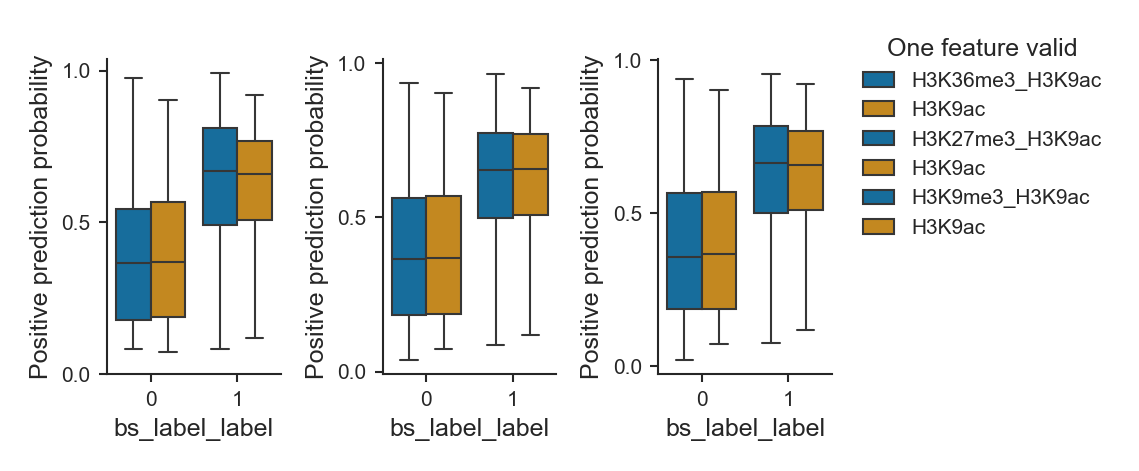

In [6]:
import scipy.stats as stats

palette = ["#B83945","#377483"]
fig, ax = plt.subplots(1,3, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))


eid = 'E116'
mark1 = 'H3K36me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bs_label_label','bs_label_score','bs_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bs_label_label','bs_label_score','bs_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)

data_1 = data[(data['bs_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bs_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_pos = stats.ttest_ind(data_1['bs_label_score'],data_2['bs_label_score'])

data_1 = data[(data['bs_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bs_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_neg = stats.ttest_ind(data_1['bs_label_score'],data_2['bs_label_score'])
print(p_value_pos,p_value_neg)

sns.boxplot(data=data,x='bs_label_label',y='bs_label_score',hue='keep_marks',fliersize=0,ax=ax[0],linewidth=0.5)


ax[0].set_ylabel(f'Positive prediction probability',fontsize=6)
# ax[0].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
# ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[0].set_yticks([i/10 for i in range(0,11,5)])
ax[0].legend().remove()



eid = 'E116'
mark1 = 'H3K27me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bs_label_label','bs_label_score','bs_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bs_label_label','bs_label_score','bs_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)




data_1 = data[(data['bs_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bs_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_pos = stats.ttest_ind(data_1['bs_label_score'],data_2['bs_label_score'])

data_1 = data[(data['bs_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bs_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_neg = stats.ttest_ind(data_1['bs_label_score'],data_2['bs_label_score'])
print(p_value_pos,p_value_neg)

sns.boxplot(data=data,x='bs_label_label',y='bs_label_score',hue='keep_marks',fliersize=0,ax=ax[1],linewidth=0.5)


ax[1].set_ylabel(f'Positive prediction probability',fontsize=6)
# ax[1].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
# ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[1].set_yticks([i/10 for i in range(0,11,5)])
ax[1].legend().remove()


eid = 'E116'
mark1 = 'H3K9me3'
mark2 = 'H3K9ac'

data1 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data1['mark1'] = data1.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)
data1['mark2'] = data1.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)

data2 = pd.read_csv('extra/results/keep_marks_predictions_bs_bf.csv')
data2['mark1'] = data2.apply(lambda row: row['keep_marks'].split('_')[1],axis=1)
data2['mark2'] = data2.apply(lambda row: row['keep_marks'].split('_')[0],axis=1)

data = pd.concat([data1,data2],axis=0)

data = data[(data['mark1']==mark1) & (data['mark2']==mark2) & (data['eid']==eid)]
data = data[['gene_id','bs_label_label','bs_label_score','bs_label_pred','eid','fold','keep_marks']]


data2 = pd.read_csv(f'extra/results/single_mark_predictions_bs_bf.csv')

data2 = data2[(data2['keep_marks']==mark2) & (data2['eid']==eid)]

data2 = data2[['gene_id','bs_label_label','bs_label_score','bs_label_pred','eid','fold','keep_marks']]

data = pd.concat([data,data2],axis=0)


data_1 = data[(data['bs_label_label']==1) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bs_label_label']==1) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_pos = stats.ttest_ind(data_1['bs_label_score'],data_2['bs_label_score'])

data_1 = data[(data['bs_label_label']==0) & (data['keep_marks']=='H3K9ac')]
data_2 = data[(data['bs_label_label']==0) & (data['keep_marks']==f'{mark1}_H3K9ac')]
t_stat, p_value_neg = stats.ttest_ind(data_1['bs_label_score'],data_2['bs_label_score'])
print(p_value_pos,p_value_neg)

sns.boxplot(data=data,x='bs_label_label',y='bs_label_score',hue='keep_marks',fliersize=0,ax=ax[2],linewidth=0.5)


ax[2].set_ylabel(f'Positive prediction probability',fontsize=6)
# ax[2].set_xlabel(f'Positive prediction probability\n({mark1}_{mark2} model)',fontsize=6)
# ax[0].set_xticks([i/10 for i in range(0,11,5)])
ax[2].set_yticks([i/10 for i in range(0,11,5)])
ax[2].legend().remove()

fig.legend(title="One feature valid",loc='upper left', bbox_to_anchor=(1, 1.05),title_fontsize=6,fontsize=5,handlelength=1.5,edgecolor='none')  

plt.show()

## Label shift valid

In [14]:
eid = 'E116'
fold = 0

for eid in ['E003','E116','E118']:
    for fold in [0,1,2,3]:
        predictions = pd.read_csv('extra/results/predictions_bs_bf_txburst_to_deeptx.csv')

        data = predictions[(predictions['eid']==eid) & (predictions['fold']==fold)]

        fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
        roc_auc = metrics.auc(fpr, tpr)
        
print(roc_auc)


data = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')


0.780108571879026


In [17]:
targets=['bs_label','bf_label']
predictions = pd.read_csv('extra/results/predictions_bs_bf_txburst_to_deeptx.csv')
with open('extra/results/bs_bf_txburst_to_deeptx_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')      
    for eid in ['E003','E116','E118']:
        for fold in [0,1,2,3]:
            data = predictions[(predictions['eid']==eid) & (predictions['fold']==fold)]
            for target in targets:
                fpr, tpr, _ = metrics.roc_curve(data[f'{target}_label'], data[f'{target}_score'])
                roc_auc = metrics.auc(fpr, tpr)
                line = [eid,str(fold),str(roc_auc*100),target]
                w.write(','.join(line) + '\n')

indicators = pd.read_csv('extra/results/bs_bf_txburst_to_deeptx_indicators.csv')
indicators

,eid,fold,auc,target
0,E003,0,77.790526,bs_label
1,E003,0,93.903359,bf_label
2,E003,1,78.581582,bs_label
3,E003,1,94.958457,bf_label
4,E003,2,80.422262,bs_label
5,E003,2,95.644475,bf_label
6,E003,3,78.349558,bs_label
7,E003,3,95.346103,bf_label
8,E116,0,78.010857,bs_label
9,E116,0,96.949591,bf_label


In [5]:
targets=['bs_label','bf_label']
predictions = pd.read_csv('extra/results/predictions_bs_bf_deeptx_to_txburst.csv')
with open('extra/results/bs_bf_deeptx_to_txburst_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')      
    for eid in ['E003','E116','E118']:
        for fold in [0,1,2,3]:
            data = predictions[(predictions['eid']==eid) & (predictions['fold']==fold)]
            for target in targets:
                fpr, tpr, _ = metrics.roc_curve(data[f'{target}_label'], data[f'{target}_score'])
                roc_auc = metrics.auc(fpr, tpr)
                line = [eid,str(fold),str(roc_auc*100),target]
                w.write(','.join(line) + '\n')

indicators = pd.read_csv('extra/results/bs_bf_deeptx_to_txburst_indicators.csv')
indicators

,eid,fold,auc,target
0,E003,0,81.192809,bs_label
1,E003,0,93.413101,bf_label
2,E003,1,80.463586,bs_label
3,E003,1,93.798426,bf_label
4,E003,2,82.242986,bs_label
5,E003,2,93.754548,bf_label
6,E003,3,80.983202,bs_label
7,E003,3,94.698266,bf_label
8,E116,0,89.727977,bs_label
9,E116,0,88.400612,bf_label


In [4]:
targets=['bs_label','bf_label']
predictions = pd.read_csv('extra/results/predictions_bs_bf_txburst_to_deeptx.csv')
with open('extra/results/bs_bf_txburst_to_deeptx_indicators.csv','w') as w:
    line = ['eid','fold','auc','target']
    w.write(','.join(line) + '\n')      
    for eid in ['E003','E116','E118']:
        for fold in [0,1,2,3]:
            data = predictions[(predictions['eid']==eid) & (predictions['fold']==fold)]
            for target in targets:
                fpr, tpr, _ = metrics.roc_curve(data[f'{target}_label'], data[f'{target}_score'])
                roc_auc = metrics.auc(fpr, tpr)
                line = [eid,str(fold),str(roc_auc*100),target]
                w.write(','.join(line) + '\n')

indicators = pd.read_csv('extra/results/bs_bf_txburst_to_deeptx_indicators.csv')
indicators

,eid,fold,auc,target
0,E003,0,78.372903,bs_label
1,E003,0,94.088650,bf_label
2,E003,1,79.313584,bs_label
3,E003,1,95.111690,bf_label
4,E003,2,80.363815,bs_label
5,E003,2,95.541761,bf_label
6,E003,3,79.260427,bs_label
7,E003,3,95.507993,bf_label
8,E116,0,78.212879,bs_label
9,E116,0,96.925168,bf_label


# motif analysis

In [25]:
predictions = pd.read_csv('extra/results/predictions_bs_bf.csv')
motifs = pd.read_csv('extra/datasets/genomic/gene_ids_with_labels.bed',sep='\t',usecols=['gene_id', 'tata_label', 'initiator_label', 'ccaat_label', 'gcbox_label']).drop_duplicates().reset_index(drop=True)
motifs

data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)


In [26]:
def compute_label_1_ratio(data, group_col, value_col):
    """
    计算 group_col == 1 的 value_col 均值在所有分组均值之和中的占比。

    参数:
    - data: DataFrame，包含需要分析的数据
    - group_col: str，用于分组的列名（例如 'bs_label_label'）
    - value_col: str，要求均值的目标列名（例如 'tata_label'）

    返回:
    - ratio: float，标签为1的分组均值在总均值中所占比例
    """
    grouped = data[[group_col, value_col]].groupby(group_col, as_index=False).mean()
    grouped = grouped.rename(columns={
        group_col: 'Group_Label',
        value_col: 'Value_Mean'
    })

    total_mean = grouped['Value_Mean'].sum()
    label_1_mean = grouped[grouped['Group_Label'] == 1]['Value_Mean'].values[0]
    ratio = label_1_mean / total_mean

    return ratio

In [17]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_pred', 'tata_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_pred', 'tata_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.3803
BF_Label = 1 的占比为: 0.3105


In [20]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_label', 'initiator_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_label', 'initiator_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.5253
BF_Label = 1 的占比为: 0.5028


In [21]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_label', 'ccaat_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_label', 'ccaat_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.5689
BF_Label = 1 的占比为: 0.5838


In [22]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_label', 'gcbox_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_label', 'gcbox_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.5629
BF_Label = 1 的占比为: 0.5933


In [27]:
targets = ['bs_label_label','bf_label_label']
motifs = ['tata_label', 'initiator_label', 'ccaat_label', 'gcbox_label']
with open('extra/results/bs_bf_motif_indicators.csv','w') as w:
    line = ['target','motif','ratio']
    w.write(','.join(line) + '\n')      
    for target in targets:
        for motif in motifs:
            ratio = compute_label_1_ratio(data, target, motif)
            line = [target,motif,str(ratio)]
            w.write(','.join(line) + '\n')

<Axes: xlabel='motif', ylabel='ratio'>

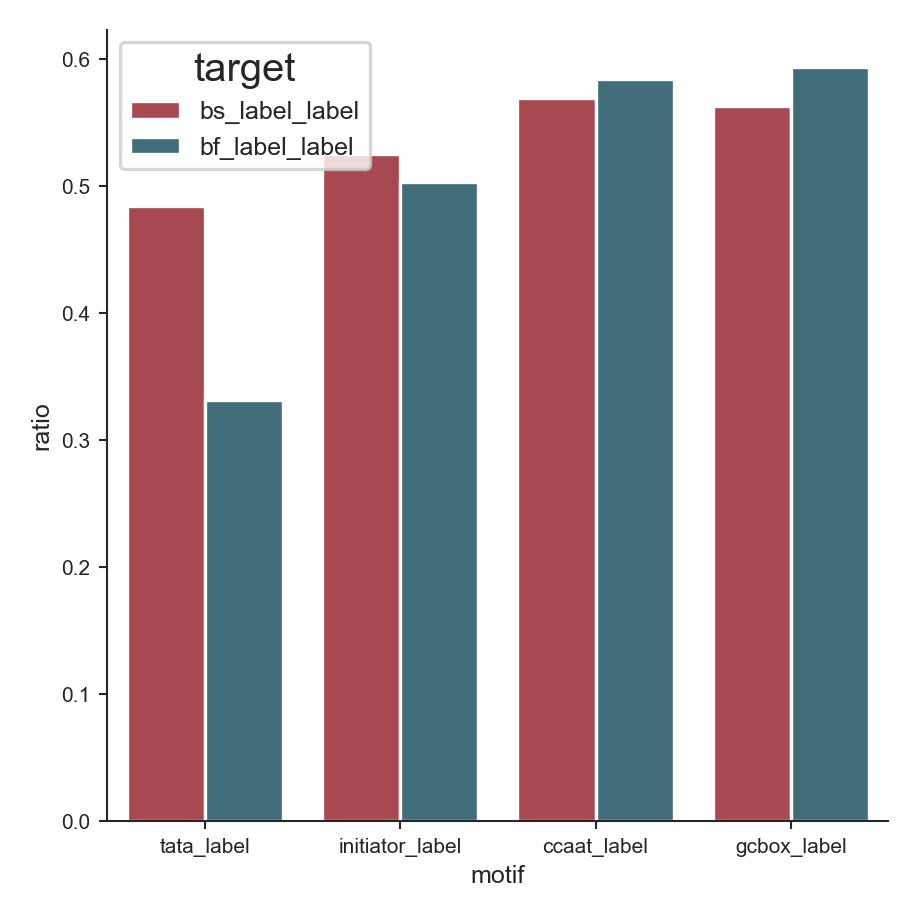

In [28]:
motif_indicatores = pd.read_csv('extra/results/bs_bf_motif_indicators.csv')
motif_indicatores

sns.barplot(data=motif_indicatores,x='motif',y='ratio',hue='target',palette=['#B83945','#377483'])

In [29]:
targets = ['bs_label_pred','bf_label_pred']
motifs = ['tata_label', 'initiator_label', 'ccaat_label', 'gcbox_label']
with open('extra/results/bs_bf_motif_indicators_pred.csv','w') as w:
    line = ['target','motif','ratio']
    w.write(','.join(line) + '\n')      
    for target in targets:
        for motif in motifs:
            ratio = compute_label_1_ratio(data, target, motif)
            line = [target,motif,str(ratio)]
            w.write(','.join(line) + '\n')

<Axes: xlabel='motif', ylabel='ratio'>

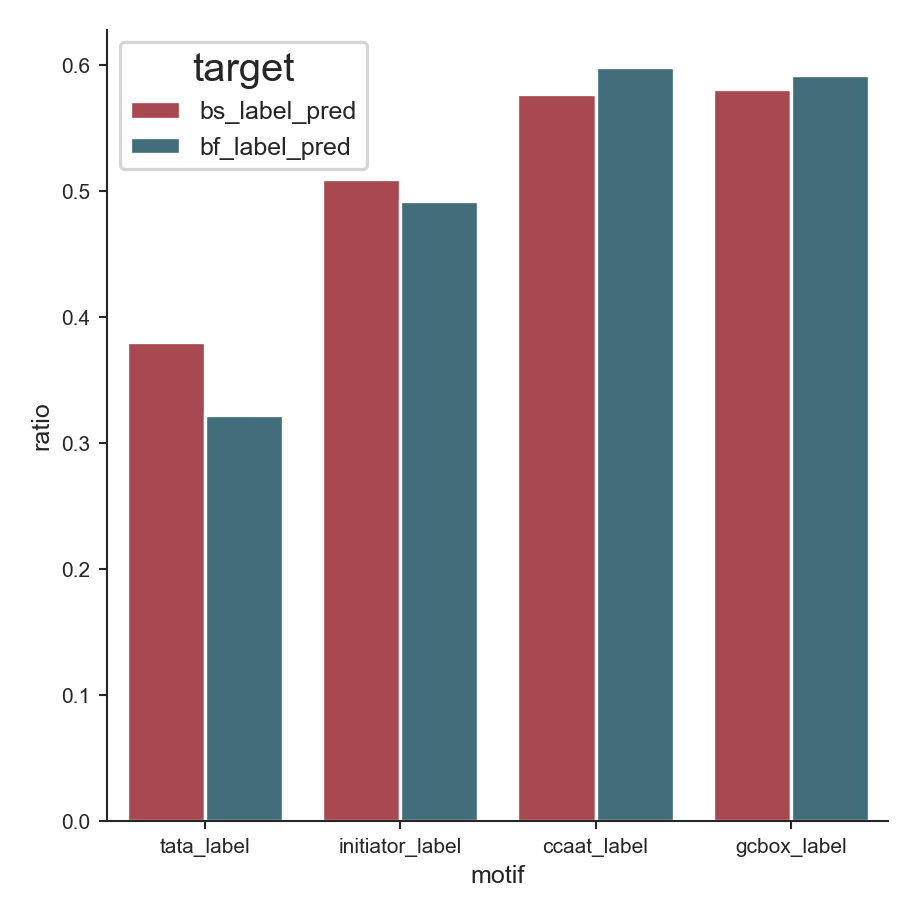

In [30]:
motif_indicatores = pd.read_csv('extra/results/bs_bf_motif_indicators_pred.csv')
motif_indicatores
sns.barplot(data=motif_indicatores,x='motif',y='ratio',hue='target',palette=['#B83945','#377483'])

In [13]:
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E118']
print(data[['bs_label_pred', 'initiator_label']].groupby(['bs_label_pred'],as_index=False).mean())
print(data[['bf_label_pred', 'initiator_label']].groupby(['bf_label_pred'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E003']
print(data[['bs_label_label', 'initiator_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'initiator_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E116']
print(data[['bs_label_label', 'initiator_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'initiator_label']].groupby(['bf_label_label'],as_index=False).mean())

   bs_label_pred  initiator_label
0              0         0.417394
1              1         0.410097
   bf_label_pred  initiator_label
0              0         0.436352
1              1         0.396231
   bs_label_label  initiator_label
0               0         0.383856
1               1         0.417963
   bf_label_label  initiator_label
0               0         0.392681
1               1         0.408455
   bs_label_label  initiator_label
0               0         0.361911
1               1         0.415810
   bf_label_label  initiator_label
0               0         0.380638
1               1         0.397631


In [86]:
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E118']
print(data[['bs_label_label', 'ccaat_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'ccaat_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E003']
print(data[['bs_label_label', 'ccaat_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'ccaat_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E116']
print(data[['bs_label_label', 'ccaat_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'ccaat_label']].groupby(['bf_label_label'],as_index=False).mean())

   bs_label_label  ccaat_label
0               0     0.211671
1               1     0.252937
   bf_label_label  ccaat_label
0               0     0.205764
1               1     0.255973
   bs_label_label  ccaat_label
0               0     0.188708
1               1     0.252067
   bf_label_label  ccaat_label
0               0     0.170411
1               1     0.267772
   bs_label_label  ccaat_label
0               0     0.176309
1               1     0.254370
   bf_label_label  ccaat_label
0               0     0.178881
1               1     0.252766


In [87]:
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E118']
print(data[['bs_label_label', 'gcbox_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'gcbox_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E003']
print(data[['bs_label_label', 'gcbox_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'gcbox_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E116']
print(data[['bs_label_label', 'gcbox_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'gcbox_label']].groupby(['bf_label_label'],as_index=False).mean())

   bs_label_label  gcbox_label
0               0     0.514378
1               1     0.589294
   bf_label_label  gcbox_label
0               0     0.470061
1               1     0.626240
   bs_label_label  gcbox_label
0               0     0.452241
1               1     0.601373
   bf_label_label  gcbox_label
0               0     0.407517
1               1     0.639935
   bs_label_label  gcbox_label
0               0     0.426702
1               1     0.599229
   bf_label_label  gcbox_label
0               0     0.414372
1               1     0.613823
